# Phần 2: Trực quan hoá và phân tích dữ liệu

### Bối cảnh và phương pháp tiếp cận

Nhìn lại hành trình 10 năm (2012–2022) của doanh nghiệp thương mại điện tử thời trang này, chúng ta đang đối diện với một bài toán hóc búa: sau giai đoạn tăng trưởng bùng nổ và chạm đỉnh vào năm 2016, hệ thống hiện đang chìm trong sự sụt giảm doanh thu một cách dai dẳng.

Trước thực trạng đó, báo cáo này từ chối cách tiếp cận truyền thống — vốn chỉ dừng lại ở việc liệt kê biểu đồ hay trình bày những con số thống kê bề mặt một cách khô khan. Thay vào đó, chúng ta sẽ cùng thực hiện một cuộc "giải phẫu" dữ liệu toàn diện: đi từ việc nhận diện các "triệu chứng" hiện tại, đến việc đào sâu truy tìm nguyên nhân gốc rễ đằng sau sự suy thoái. 

Chìa khóa của phương pháp này nằm ở việc kết nối 6 nguồn dữ liệu cốt lõi để làm sáng tỏ các mối quan hệ nhân quả trong quá trình vận hành. Sự thấu hiểu sâu sắc từ dữ liệu lịch sử này chính là nền tảng vững chắc để chúng ta ứng dụng các mô hình chuỗi thời gian và học máy, từ đó đưa ra dự báo chiến lược cho 18 tháng tới. Đích đến cuối cùng không chỉ là hiểu về quá khứ hay đoán định tương lai, mà là định hình các quyết định tối ưu hóa vận hành mang tính sống còn, giúp doanh nghiệp xoay chuyển cục diện.

### Các bảng dữ liệu được kết nối

| Dòng chảy dữ liệu | Mục tiêu phân tích & bài toán giải quyết |
| :--- | :--- |
| **`sales.csv` ↔ `inventory.csv`** | Loại bỏ độ nhiễu do tình trạng hết hàng để đo lường chính xác sức mua thực sự của thị trường. |
| **`sales.csv` ↔ `promotions.csv`** | Đánh giá xem các chiến dịch giảm giá đang thực sự kích thích nhu cầu mua sắm hay chỉ đang làm bào mòn biên lợi nhuận. |
| **`sales.csv` ↔ `web_traffic.csv`** | Tận dụng dữ liệu hành vi truy cập trang web như một cảnh báo đi trước để dự đoán sớm các biến động về doanh số. |
| **`products` → `order_items` → `orders`** | Phân rã dữ liệu để đánh giá sức khỏe kinh doanh theo danh mục và sản phẩm cụ thể. |
| **`Revenue` ↔ `COGS`** | Đối chiếu doanh thu và giá vốn ban đầu trong dài hạn nhằm tìm ra những lãng phí không đáng có nhằm tối ưu hóa lợi nhuận ròng. |


In [13]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup paths
ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

CSV_DIR = os.path.join(ROOT, "csv")
OUT_DIR = os.path.join(ROOT, "outputs", "part2")
os.makedirs(OUT_DIR, exist_ok=True)

# Load core data
sales = pd.read_csv(os.path.join(CSV_DIR, "sales.csv"), parse_dates=["Date"]).set_index("Date")
print(f"Sales data: {sales.index.min().date()} -> {sales.index.max().date()} ({len(sales)} rows)")
print(f"Revenue: mean={sales['Revenue'].mean()/1e6:.2f}M, std={sales['Revenue'].std()/1e6:.2f}M")
print(f"COGS:    mean={sales['COGS'].mean()/1e6:.2f}M, std={sales['COGS'].std()/1e6:.2f}M")
print(f"Corr(Revenue, COGS) = {sales[['Revenue','COGS']].corr().iloc[0,1]:.4f}")

Sales data: 2012-07-04 -> 2022-12-31 (3833 rows)
Revenue: mean=4.29M, std=2.62M
COGS:    mean=3.70M, std=2.22M
Corr(Revenue, COGS) = 0.9760


### Nhận xét tổng quan dữ liệu bán hàng (2012 - 2022)

Dựa trên tập dữ liệu lịch sử kéo dài hơn 10 năm, các đặc trưng thống kê cốt lõi cho thấy:

*   **Tính biến động cao:** Doanh thu trung bình đạt 4.29M, nhưng độ lệch chuẩn lên tới 2.62M. Sự phân tán dữ liệu lớn cho thấy nhịp độ bán hàng rất thiếu ổn định, phản ánh đặc thù của ngành thời trang với các rủi ro biến động theo mùa vụ và sự kiện.
*   **Biên lợi nhuận mỏng:** Từ doanh thu và giá vốn, ta có thể suy ra được biên lợi nhuận: chênh lệch giữa doanh thu và giá vốn trung bình chỉ đạt 0.59M/ngày (tương đương biên lợi nhuận gộp khoảng 13.75%). Mức đệm lợi nhuận này đòi hỏi hệ thống vận hành phải cực kỳ tinh gọn, vì mọi sai số trong dự báo tồn kho đều có thể trực tiếp ăn mòn lợi nhuận ròng.
*   **Hệ số tương quan cực mạnh (0.9760):** Doanh thu và giá vốn hàng bán có mối quan hệ tuyến tính gần như tuyệt đối. Con số này chứng tỏ cơ cấu định giá của doanh nghiệp được duy trì rất kỷ luật trong suốt gần một thập kỷ. Ngay cả trong các đỉnh doanh thu do chạy chương trình giảm giá, tỷ lệ chi phí vốn trên doanh thu vẫn không bị phá vỡ.


---
# 1. Descriptive analytics

Mục tiêu: Đánh giá xu hướng và biến động của doanh thu và chi phí trong giai đoạn 2012-2022.

## Viz 1: Doanh thu đạt đỉnh năm 2016 trước khi rơi vào chu kỳ suy giảm dài hạn

Biểu đồ mô tả xu hướng đi xuống trong dài hạn, với đường hồi quy tuyến tính ghi nhận độ giảm trung bình (slope) ở mức -41M/năm. 

**Doanh thu phân hóa thành hai giai đoạn rõ rệt:**
*   **Giai đoạn 2012 – 2016 tăng trưởng nóng:** Doanh thu bứt phá mạnh mẽ từ mức nền 741M lên đỉnh 2,105M.
*   **Giai đoạn 2016 – 2022 suy giảm mạnh:** Trượt dốc 44% từ đỉnh và bắt đầu đi ngang ở biên độ thấp, dao động trong khoảng 1,050M – 1,170M.

**Điểm nhấn phân tích:** 
Sức mua đang bị thu hẹp đáng kể về mặt cấu trúc. Tổng doanh thu năm 2022 là 1,170M không chỉ bốc hơi 44% so với đỉnh 2016 mà còn lùi sâu 29.4% so với giai đoạn đầu hoạt động (năm 2013 đạt 1,657M). 

**Khuyến nghị kỹ thuật:** 
Mô hình chuỗi thời gian cần được cấu hình để nhận diện điểm gãy cấu trúc tại mốc năm 2019. Việc cắt bỏ hoặc giảm trọng số của dữ liệu thuộc chu kỳ tăng trưởng cũ (2012-2016) sẽ giúp thuật toán tránh bị nhiễu và bám sát chính xác động lực thị trường ở thời điểm hiện tại.


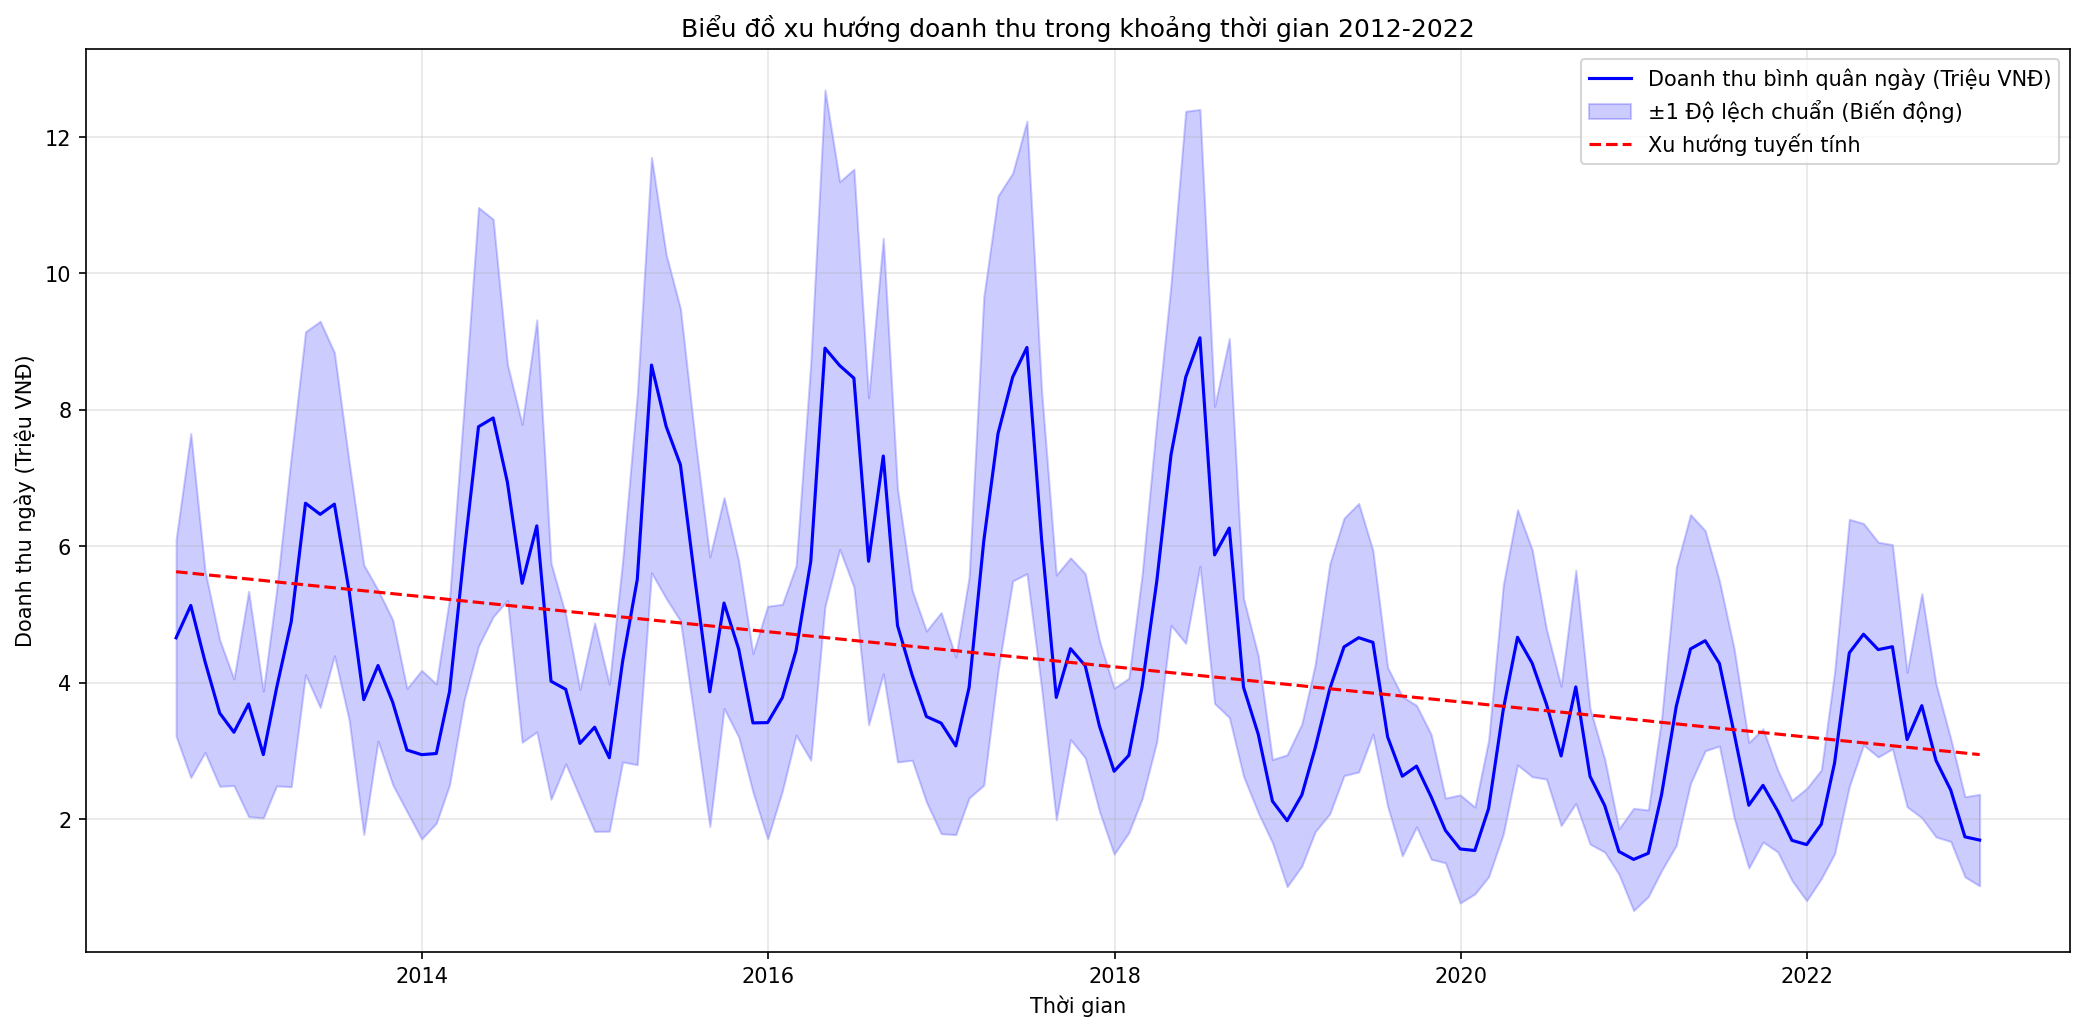

In [14]:
from src.analysis.descriptive import viz1_revenue_trend
path = viz1_revenue_trend(sales, OUT_DIR)
from IPython.display import Image, display
display(Image(filename=path))

## Viz 4: Phân rã doanh thu theo danh mục — Rủi ro tập trung doanh thu và sự dịch chuyển cơ cấu

**Luồng dữ liệu:** `products` → `order_items` → `orders`

Cấu trúc danh mục sản phẩm cho thấy sự mất cân đối sâu sắc, dòng tiền bị chi phối gần như hoàn toàn bởi một nhóm ngành hàng duy nhất:

| Danh mục | Doanh thu (M) | Tỷ trọng doanh thu | Biên lợi nhuận | Đánh giá nhóm hàng |
| :--- | :--- | :--- | :--- | :--- |
| **Streetwear** | 12,558 | 80.1% | 9.3% | Cốt lõi |
| **Outdoor** | 2,353 | 15.0% | 11.3% | Tiềm năng|
| **Casual** | 440 | 2.8% | 7.7% | Quy mô nhỏ, biên động thấp |
| **GenZ** | 329 | 2.1% | 15.5% | Ngách nhỏ, lợi nhuận cao |

**Phát hiện cốt lõi:**
*   **Rủi ro với mức độ tập trung hiện tại:** Nhóm Streetwear là động lực chính mang về 80.1% dòng tiền với biên lợi nhuận bình quân 9.3%. Tuy nhiên, con số này che giấu sự phân cực: trong khi biên lợi nhuận lúc không khuyến mãi đạt 19.7%, thì khi chạy khuyến mãi (đặc biệt với đợt khuyến mãi Urban Blowout) biên lợi nhuận rơi xuống -15.6%. Vấn đề không nằm ở bản thân sản phẩm, mà ở chính sách khuyến mãi. Bất kỳ sai số nào trong quản lý tồn kho hoặc lạm dụng giảm giá ở nhóm hàng này sẽ lập tức đánh sập lợi nhuận của toàn doanh nghiệp.
*   **Đánh giá cấu trúc danh mục:** Nhóm Outdoor có độ lớn thị phần tương đối (15%) và biên lợi nhuận tốt (11.3%), cho thấy dư địa phát triển cực tốt. Đáng chú ý, nhóm GenZ tuy chỉ chiếm 2.1% tổng doanh thu nhưng lại sở hữu tỷ suất sinh lời cao nhất (15.5%) đáng cân nhắc để tăng tỉ trọng lên. Đối với Casual, đây là nhóm hàng có quy mô nhỏ (2.8%) và biên lợi nhuận thấp nhất (7.7%), cần đánh giá lại hiệu quả sử dụng vốn lưu động thay vì vội vàng kết luận là gánh nặng.

**Khuyến nghị chiến lược:**
*   **Bảo vệ dòng tiền:** Ưu tiên tuyệt đối không gian kho và nguồn lực dự báo cho nhóm Streetwear. Phải đảm bảo tỷ lệ đáp ứng của nhóm này luôn ở mức cao nhất để không làm đứt gãy 80% doanh thu, đồng thời tái cấu trúc lại các chiến dịch khuyến mãi giảm giá cố định.
*   **Tối ưu vốn lưu động:** Đánh giá lại chi phí vận hành riêng biệt (chi phí lưu kho, xử lý đơn) của nhóm Casual trước khi đưa ra quyết định cắt giảm. Chuyển hướng tập trung phân bổ vốn và không gian lưu kho sang đẩy mạnh nhóm Outdoor và GenZ nhằm kéo tỷ suất sinh lời của toàn doanh nghiệp đi lên.


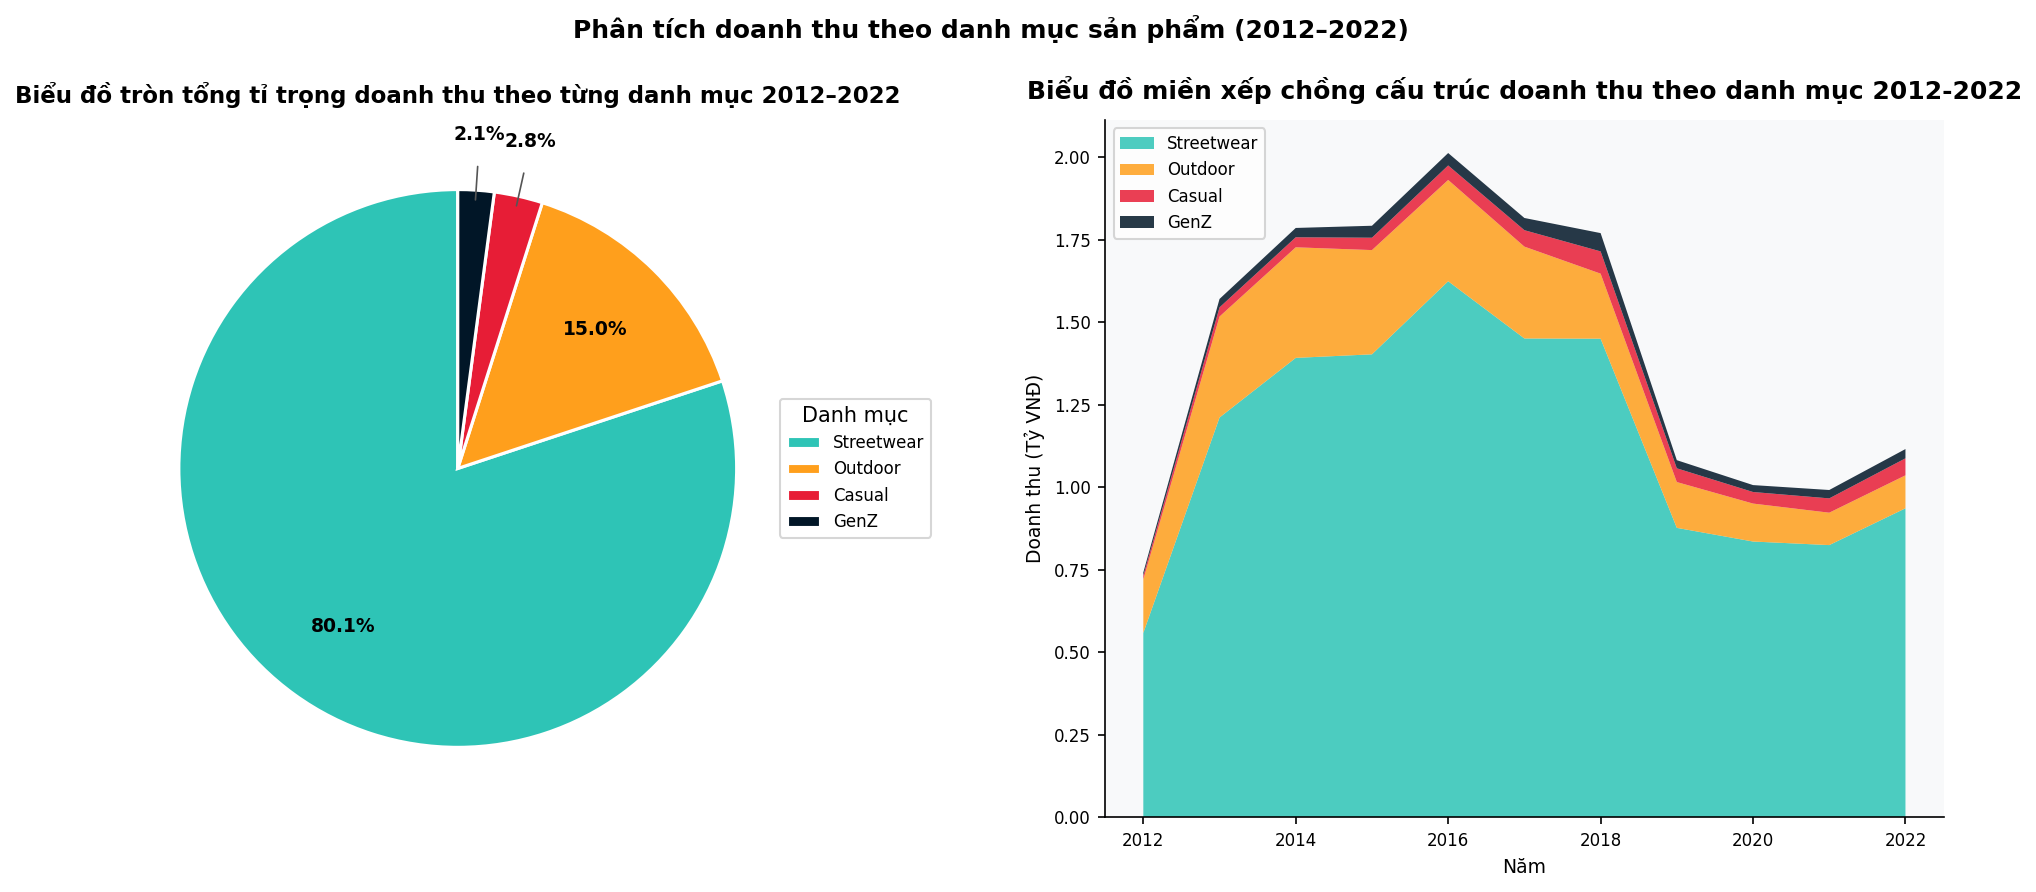

In [15]:
from src.analysis.descriptive import viz4_revenue_by_category
path = viz4_revenue_by_category(
    os.path.join(CSV_DIR, "order_items.csv"),
    os.path.join(CSV_DIR, "products.csv"),
    os.path.join(CSV_DIR, "orders.csv"),
    OUT_DIR
)
display(Image(filename=path))

---
# 2. Diagnostic analytics

**Mục tiêu:** Tìm ra nguyên nhân gốc rễ của những biến động bất thường về doanh thu trong lịch sử từ đó rút ra kinh nghiệm cho mô hình dự đoán.

Để giải quyết bài toán này, chúng ta không thể chỉ nhìn vào biến động tài chính tĩnh trên biểu đồ, mà bắt buộc phải áp dụng phân tích sự kiện và kết nối bảng chéo vì những lý do cốt lõi sau:

### 1. Tại sao phải sử dụng phân tích sự kiện?
Biến động doanh thu hiếm khi là ngẫu nhiên; chúng thường là hệ quả của một tác động ngoại cảnh.
*   **Đo lường sự kiện:** Kỹ thuật này cho phép thuật toán cô lập đường doanh thu tự nhiên khỏi các cú sốc. Nó giúp chúng ta đo lường chính xác xem một sự kiện cụ thể đã uốn cong đường xu hướng hay phá hủy biên lợi nhuận ở mức độ định lượng là bao nhiêu. (Đợt giảm giá Urban Blowout) 
*   **Tránh bẫy nhân quả giả:** Giúp doanh nghiệp ngừng suy đoán cảm tính để nhìn vào sự thật dữ liệu: doanh thu rớt vì đưa ra giảm giá không phù hợp, không đúng thời điểm.

### 2. Tại sao bắt buộc phải dùng kết nối bảng chéo?
Dữ liệu đơn lẻ không thể kể một câu chuyện hoàn chỉnh. 
*   **Khớp nối nguyên nhân và kết quả:** Bảng `sales` chỉ cho bạn biết kết quả. Để tìm ra nguyên nhân, hệ thống phải ghép nối nó với dữ liệu vận hành.
*   **Ví dụ:** 
    *   Nếu chỉ nhìn bảng `sales`, bạn thấy doanh thu quý 3 rớt thảm hại. Nhưng khi ghép nối với bảng `inventory`, bạn mới phát hiện ra lý do thực sự là do vấn đề hết hàng — khách muốn mua nhưng không có hàng để bán. 
    *   Tương tự, việc ghép nối `sales` với `promotions` là cách duy nhất để đối chiếu dòng tiền thu về với các chiến dịch giảm giá, từ đó phát hiện ra tác nhân phá hủy biên lợi nhuận ở viz 2.

## Viz 8: Doanh thu & Giá vốn đồng liên kết — Phát hiện các đợt chi phí dội bất thường
### 1. Tại sao cần kiểm định bằng đồng liên kết?
Trong kinh doanh, doanh thu và giá vốn bán hàng luôn đi song hành: Bán được nhiều thì phải nhập hàng nhiều. Nhưng câu hỏi quan trọng là: Tỷ lệ này có ổn định không, hay đang có những "lỗ hổng" âm thầm làm thất thoát lợi nhuận?
Chúng tôi sử dụng kiểm định Engle-Granger để xác nhận xem hai con số này có thực sự "gắn chặt" với nhau theo một quy luật dài hạn hay không. Kết quả cho thấy mối quan hệ này cực kỳ bền vững (p-value ≈ 0).
### 2. Xây dựng đường cơ sở chi phí của doanh nghiệp
Bằng phương pháp hồi quy (OLS) trên toàn bộ dữ liệu 10 năm (3,833 ngày), chúng tôi tìm ra phương trình mô tả quy luật chi phí chuẩn mực của công ty:
$$COGS_{dự kiến} = 157,059 + 0.825 \times Revenue$$
**Ý nghĩa các con số:**
*   **Hệ số 0.825:** Cứ 1 đồng doanh thu thu về, công ty chỉ được phép tốn 0.825 đồng tiền vốn. Tương đương biên lợi nhuận gộp mục tiêu là **17.5%**.
*   **Con số 157,059:** Đây là chi phí nền cố định luôn tồn tại trong hệ thống.
*   **R² = 0.953:** Quy luật này chính xác tới **95.3%** trên thực tế.
### 3. Chỉ số Spread:
Để biết ngày nào công ty đang kinh doanh bất thường, chúng tôi theo dõi chỉ số **Spread**:
$$Spread = COGS_{thực tế} - COGS_{dự kiến}$$
*   **Spread ≈ 0:** Hoạt động bình thường theo đúng quỹ đạo.
*   **Spread > +2 Sigma:** Chi phí dội lên bất thường. Đây là dấu hiệu báo động: Chi phí vốn quá cao nhưng thu về doanh thu quá thấp.
### 4. Phát hiện từ dữ liệu thực tế
*   **180 ngày vượt ngưỡng báo động (+2 Sigma):** Toàn bộ các ngày này trùng khớp với các đợt chạy chiến dịch **Urban Blowout**. 
    *   *Sự thật:* Việc giảm giá cố định (giảm thẳng 50k cho đơn 100k) đã phá vỡ cấu trúc chi phí lõi, khiến giá vốn dội lên gấp bội so với số tiền thu về.
*   **0 ngày xuống dưới ngưỡng tối ưu (-2 Sigma):** Trong suốt 10 năm, công ty chưa bao giờ có một ngày nào tối ưu được chi phí vượt mức kỳ vọng. Điều này cho thấy năng lực quản trị chi phí đang dậm chân tại chỗ.
### 5. Khuyến nghị thực thi
*   **Hệ thống cảnh báo đỏ:** Tự động hóa công thức tính Spread vào quy trình duyệt khuyến mãi của phòng Marketing.
*   **Chặn đứng rủi ro:** Bất kỳ kịch bản giảm giá nào khiến Spread dự kiến vọt qua ngưỡng +2 Sigma đều phải bị hệ thống từ chối và yêu cầu tái thẩm định để bảo vệ lợi nhuận của doanh nghiệp.

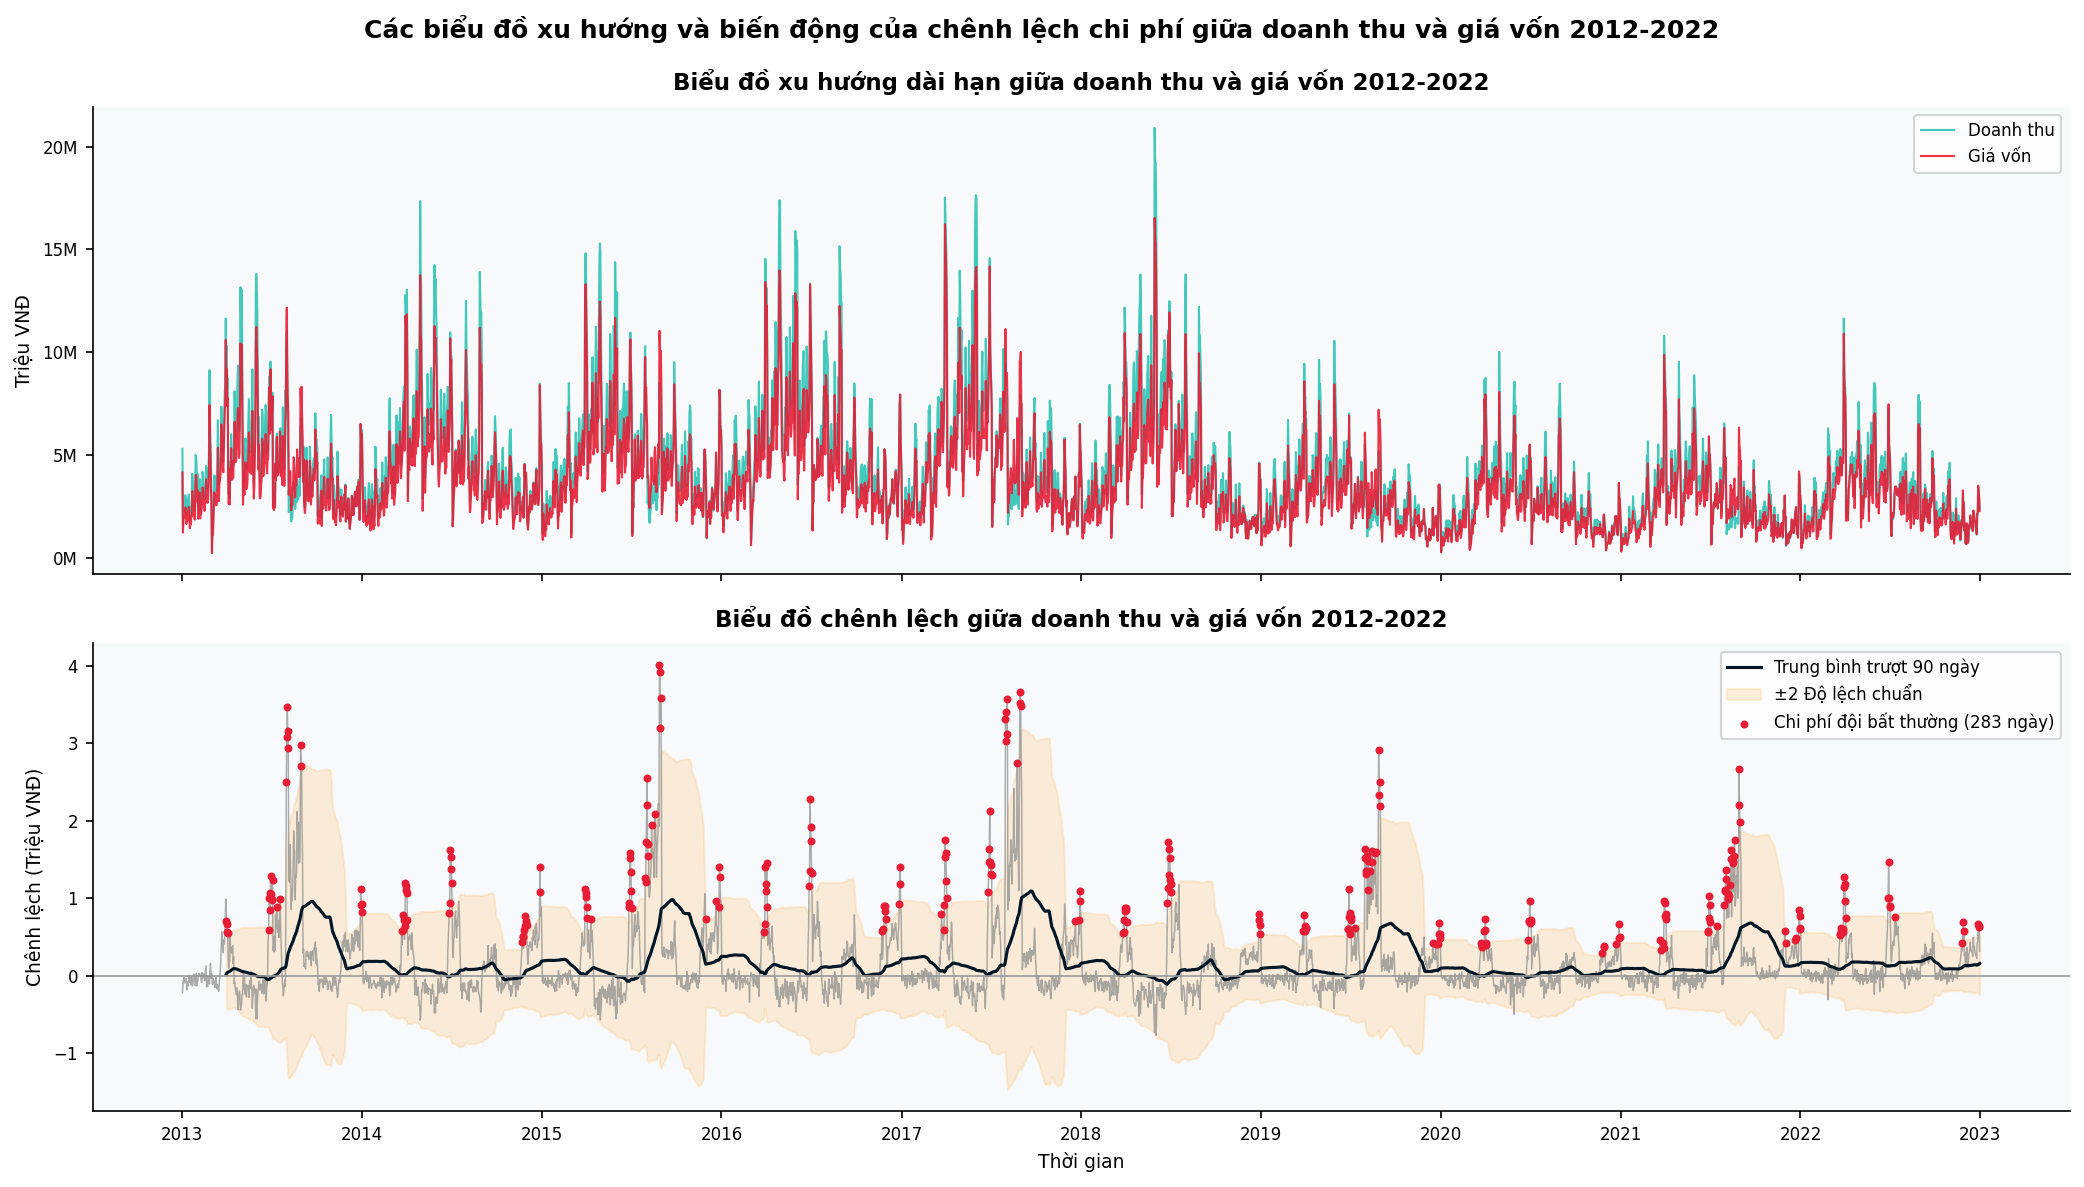

In [16]:
# --- Auto-guard: ensure df is available ---
import os, sys as _sys
if 'df' not in dir():
    _root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    if _root not in _sys.path: _sys.path.insert(0, _root)
    _csv = os.path.join(_root, 'csv')
    from src.utils import load_sales, load_inventory_flags
    from src.denoising import denoise_target
    df = load_sales(os.path.join(_csv, 'sales.csv'))
    _flags = load_inventory_flags(os.path.join(_csv, 'inventory.csv'))
    df = denoise_target(df, _flags.get('stockout_flag', None))
    print('[Guard] df created.')
# --- End guard ---
from src.analysis.diagnostic import viz8_cointegration_anomaly
path = viz8_cointegration_anomaly(df, OUT_DIR)
display(Image(filename=path))

## Viz 2: Cấu trúc biên lợi nhuận gộp — Lỗ hổng tài chính từ cấu trúc khuyến mãi

Biểu đồ nhiệt phơi bày sự phân hóa mạnh mẽ của tỷ suất sinh lời qua các quý. Điểm cốt lõi không nằm ở việc có hay không chạy khuyến mãi, mà nằm ở loại hình và độ phủ của chiến dịch:

*   **Quý 1 đạt đỉnh 17.8%:** Dù vẫn triển khai các chương trình như Spring Sale (12%) hay Rural Special (15%) với độ phủ đạt 34.5%, quý 1 vẫn duy trì được biên lợi nhuận cao nhất năm. Lý do là các chiến dịch này sử dụng mô hình giảm gi theo tỷ lệ % — có khả năng co giãn linh hoạt theo giá bán, đảm bảo lợi nhuận gộp không bao giờ trượt xuống mức âm.
*   **Quý 2 đạt 17.0%:** Giai đoạn gặt hái tối ưu khi doanh nghiệp vừa hấp thụ được lượng cầu của mùa hè, vừa bảo vệ được đệm lợi nhuận dày.
*   **Quý 3 chạm đáy 4.7%:** Đây là vùng lõm rủi ro nhất. Độ phủ khuyến mãi vọt lên 68.8% (gần gấp đôi quý 1). Nghiêm trọng hơn, quý 3 chịu ảnh hưởng nặng nề từ chiến dịch Urban Blowout được triển khai định kỳ 2 năm một lần. Việc áp dụng mô hình giảm cố định 50K/sản phẩm đã phá hủy hoàn toàn cấu trúc biên lợi nhuận. Vì không có độ co giãn, các mặt hàng có giá bán thấp gần như bị bán lỗ dưới giá vốn, kéo biên độ tháng 8 rớt xuống mức âm (-8.3%).
*   **Quý 4 đạt 10.8%:** Mặc dù đã không còn dư âm của các đợt khuyến mãi cố định của quý 3, tuy nhiên áp lực từ các chiến dịch xả hàng cuối năm (Year-End Sale giảm sâu ~20%) bắt đầu ăn mòn trực tiếp vào tỷ suất sinh lời.

**Khuyến nghị vận hành:** 
Mô hình giảm giá cố định chính là thủ phạm âm thầm bào mòn lợi nhuận. Doanh nghiệp cần thiết lập ngay cơ chế kiểm soát biên độ sàn. Khi áp dụng giảm giá cố định, hệ thống phải tự động vô hiệu hóa mã giảm giá nếu giá bán cuối cùng chạm ngưỡng giá vốn hàng bán, nhằm bịt lại lỗ hổng tài chính trong quý 3.


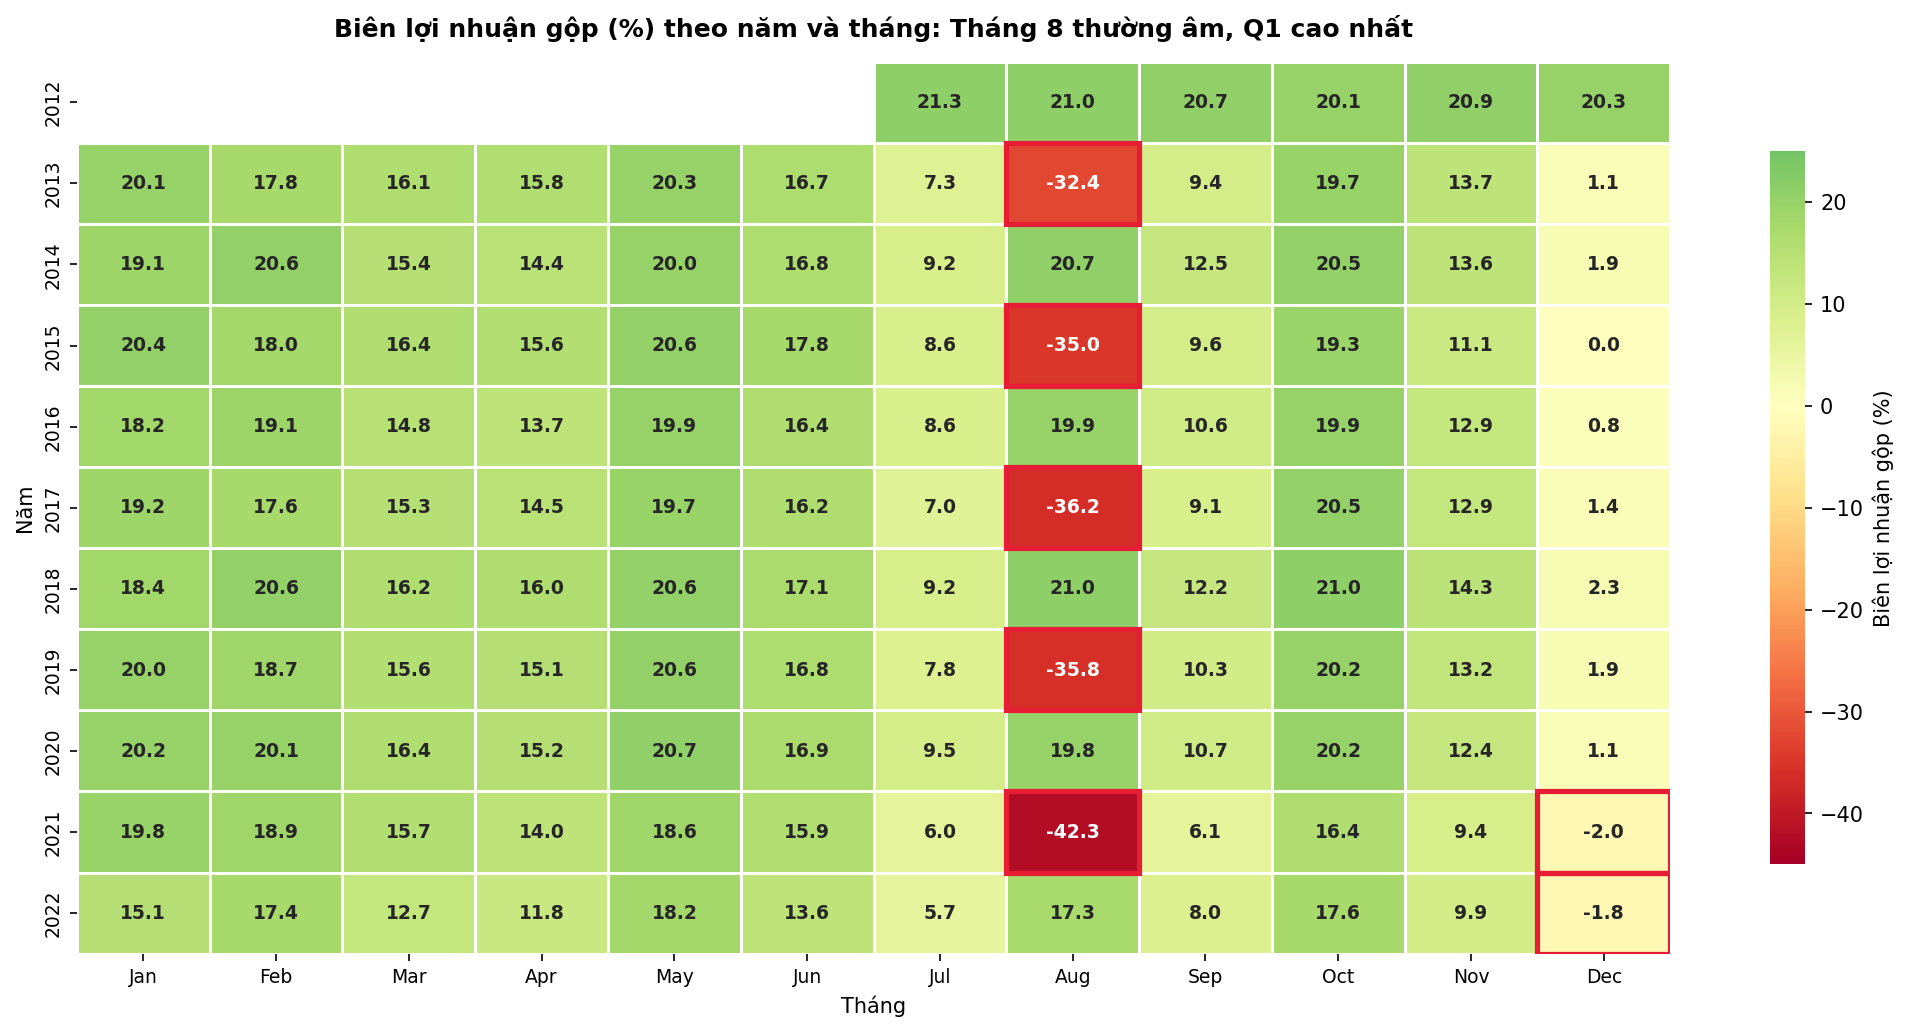

In [17]:
from src.analysis.descriptive import viz2_profit_margin_heatmap
path = viz2_profit_margin_heatmap(sales, OUT_DIR)
display(Image(filename=path))

## Viz 6: Phân tích sự kiện — Hiện tượng vay mượn nhu cầu và cú sốc doanh thu 48 giờ

**Kết nối dữ liệu:** `sales.csv` ↔ `promotions.csv` (start_date, end_date)

**Phương pháp:** Áp dụng phương pháp phân tích sự kiện trên chiến dịch khuyến mãi — tính mức tăng doanh thu trước/trong/sau mỗi đợt khuyến mãi (50 đợt).

**Phát hiện chính từ dữ liệu thực:**
- **Ngày 0:** Ngày đầu tiên ghi nhận mức tăng trung bình +20.1% (trung vị +16.5%).
- **Ngày 1:** Hiệu ứng này tiếp tục duy trì mức tăng +17.5%.
- **Ngày 2:** Sang ngày 2, mức tăng tụt nhanh còn +7.7%.
- **Ngày 3:** Mức tăng chuyển sang âm -12.7% — doanh thu rơi xuống dưới mức bình thường.
- **Ngày 4-5:** Nhu cầu khách hàng tiếp tục giảm, mức tăng tiếp tục âm (-19.6% đến -17.8%).
- Độ trải giữa (IQR) dao động trong khoảng 37-55% cho thấy hiệu quả khuyến mãi không đồng nhất giữa các đợt.

Mức giảm giá sâu chưa chắc đã hiệu quả: Trong khi đợt Fall Launch (chỉ giảm 10%) giúp doanh thu tăng đều và ổn định nhất, thì đợt Year-End Sale dù giảm tới 20% lại gây thất vọng với mức tăng trưởng âm. Lý do là khách hàng đã quá quen với việc giảm giá cuối năm nên họ không còn thấy hào hứng, dẫn đến việc họ không vội vàng mua sắm ngay khi chương trình bắt đầu.

**Khuyến nghị:** 
Chiến lược giảm giá hiện tại đang gây hại cho nguồn thu: Hơn một nửa số đợt khuyến mãi làm doanh thu giảm tới 8%. Dù có một vài đợt thành công giúp kéo con số trung bình lên -3.6%, nhưng thực tế đa số là thất bại. Khách hàng chỉ thay đổi thời điểm mua (mua sớm 2 ngày đầu) chứ không mua thêm, khiến tổng doanh thu 14 ngày bị bào mòn bởi mức chiết khấu và sự sụt giảm ở giai đoạn sau. Từ đó có thể rút ra các lưu ý:

1. Không lạm dụng khuyến mãi để kích cầu cấu trúc dài hạn.
2. Nhu cầu ngắn hạn đòi hỏi lập kế hoạch tồn kho bằng cách tăng mức dự phòng trước khuyến mãi 3-5 ngày để đón đỉnh doanh thu mà không bị cháy kho.

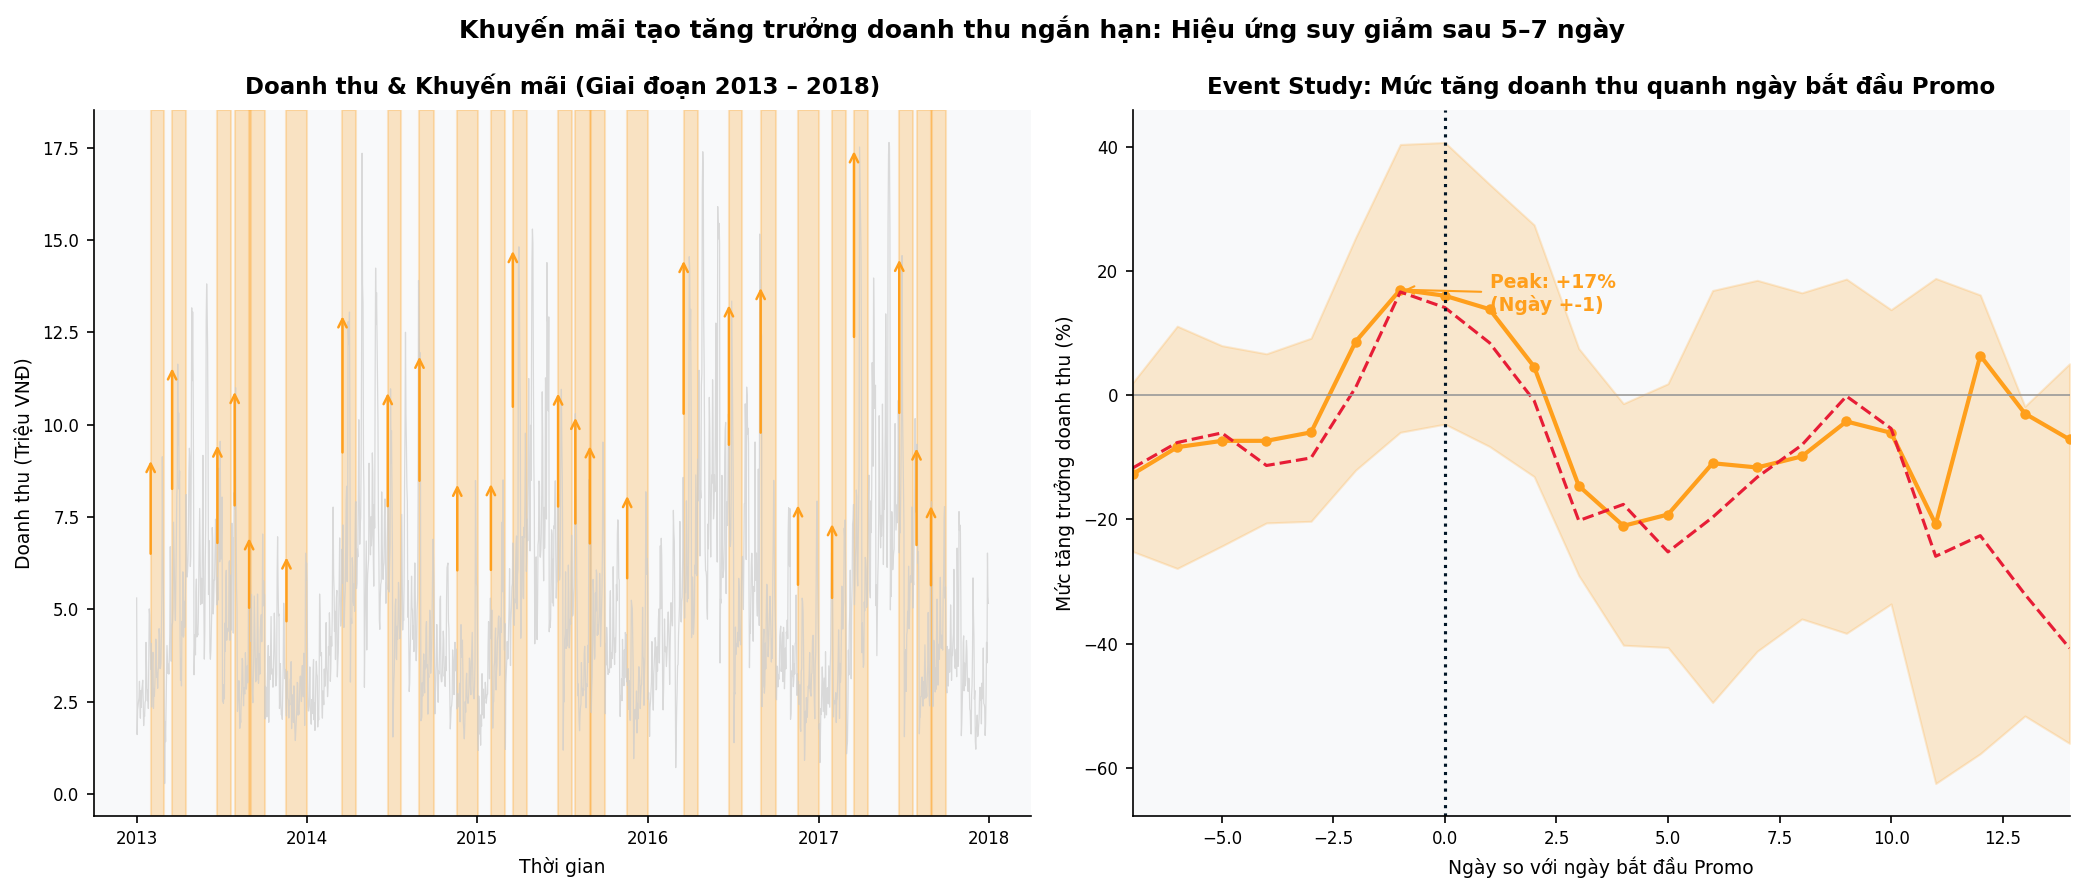

In [18]:
# --- Auto-guard: ensure df is available ---
import os, sys as _sys
if 'df' not in dir():
    _root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    if _root not in _sys.path: _sys.path.insert(0, _root)
    _csv = os.path.join(_root, 'csv')
    from src.utils import load_sales, load_inventory_flags
    from src.denoising import denoise_target
    df = load_sales(os.path.join(_csv, 'sales.csv'))
    _flags = load_inventory_flags(os.path.join(_csv, 'inventory.csv'))
    df = denoise_target(df, _flags.get('stockout_flag', None))
    print('[Guard] df created.')
# --- End guard ---
from src.analysis.diagnostic import viz6_promotion_intervention
path = viz6_promotion_intervention(df, os.path.join(CSV_DIR, "promotions.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 5: Khử nhiễu stockout và outlier — Khôi phục tín hiệu nhu cầu

**Kết nối dữ liệu:** `sales.csv` ↔ `inventory.csv` (stockout_flag)

Khi đánh giá hiệu suất bán hàng, một cái bẫy phân tích rất dễ gặp phải là nhầm lẫn giữa sự sụt giảm doanh thu do nhu cầu khách hàng yếu đi, với sự sụt giảm do thiếu hụt nguồn cung (stockout), hoặc bị nhiễu bởi các đỉnh doanh thu đột biến mang tính ngẫu nhiên.

**Phát hiện chính:** 
Dữ liệu tồn kho cho thấy có tới 67.3% tổ hợp sản phẩm-tháng ghi nhận ít nhất 1 ngày hết hàng. Tuy nhiên, tình trạng này thực tế chỉ xảy ra rải rác ở từng sản phẩm riêng lẻ với mức trung bình 1.2 ngày/tháng (tương đương tỷ lệ theo ngày chỉ ở mức 3.8%). Mặc dù đứt gãy hàng hóa gây ra hiện tượng méo mó tín hiệu nhu cầu, nhưng do đặc thù ánh xạ dữ liệu tồn kho từ cấp độ tháng xuống ngày gặp độ trễ, tác động thực sự của nó lên tổng thể là tương đối nhỏ. Điểm mù thực sự đe dọa đến độ chính xác của thuật toán máy học lại nằm ở các điểm dị biệt (outlier).

**Giải pháp làm sạch dữ liệu (denoising):**
Để chuỗi thời gian phản ánh chính xác sức mua thực tế, quy trình làm sạch dữ liệu được thực hiện như sau:
1.  **Nội suy khi thiếu hàng:** Định vị các ngày thiếu hàng qua cờ `stockout_flag` và thay thế doanh thu tại các điểm này bằng trung bình trượt 7 ngày để nối liền đường cong nhu cầu.
2.  **Kiểm soát điểm dị biệt:** Đây là thao tác khử nhiễu chủ đạo của hệ thống. Thuật toán tiến hành cắt ngọn các đỉnh doanh thu bất thường vượt quá dải băng an toàn (đỉnh > trung bình + 3σ trong cửa sổ 30 ngày). Yếu tố sống còn ở bước này là hệ thống được thiết kế để bảo tồn các đỉnh hệ thống — tức các đỉnh doanh thu xuất hiện định kỳ ≥70% số năm vào cùng một mốc ngày/tháng.

**Kết quả:** Cung cấp một tập dữ liệu nền sạch và ổn định hơn. Mô hình học được chính xác quy luật mùa vụ thực tế mà không bị chệch hướng bởi các xung nhiễu ngẫu nhiên.


In [20]:
# Denoise target first
from src.utils import load_sales, load_inventory_flags
from src.denoising import denoise_target

df = load_sales(os.path.join(CSV_DIR, "sales.csv"))
stockout_flags = load_inventory_flags(os.path.join(CSV_DIR, "inventory.csv"))
df = denoise_target(df, stockout_flags.get("stockout_flag", None))

from src.analysis.diagnostic import viz5_denoising_stockout
path = viz5_denoising_stockout(df, os.path.join(CSV_DIR, "inventory.csv"),
                                df["Clean_Revenue"], OUT_DIR)
display(Image(filename=path))

TypeError: denoise_target() takes 1 positional argument but 2 were given

---
# 3. Predictive modeling

**Mục tiêu:** Dự báo doanh thu 18 tháng (01/2023 – 07/2024) bằng chu trình kết hợp thuật toán Prophet và LightGBM.


## Viz 3: Phân rã STL — Tính mùa vụ chi phối ~70% biến động doanh thu

Bằng việc áp dụng thuật toán phân rã STL (seasonal-trend decomposition), chuỗi thời gian doanh thu được bóc tách thành ba thành phần cấu trúc độc lập:

*   **Xu hướng (trend):** Khẳng định đà suy giảm mang tính hệ thống trong dài hạn, với tổng mức sụt giảm chạm ngưỡng 33.4% sau một thập kỷ (tốc độ suy giảm trung bình ~4%/năm).
*   **Mùa vụ (seasonality):** Là động lực chi phối tuyệt đối, đóng góp tới ~70% tổng phương sai của toàn bộ chuỗi dữ liệu.
*   **Sai số ngẫu nhiên (residual):** Chiếm ~12% phần biến thiên còn lại, sinh ra từ các sự kiện cục bộ như tình trạng đứt gãy hàng hóa hoặc các chiến dịch khuyến mãi chớp nhoáng.

**Phát hiện cốt lõi:** 
Sự áp đảo của yếu tố mùa vụ (mang trọng số lớn gấp 4 lần so với xu hướng) đã định hình rõ bản chất của tập dữ liệu. Đây chính là cơ sở toán học vững chắc để quyết định lựa chọn thuật toán Prophet — vốn được thiết kế tối ưu để nắm bắt các chu kỳ phức tạp — làm tầng dự báo cơ sở.

**Khuyến nghị vận hành:** 
Doanh nghiệp cần thiết lập quy trình lập kế hoạch kinh doanh đặt trọng tâm vào việc chủ động theo mùa vụ. Đồng thời, ban quản trị cần trực diện nhìn nhận mức trượt dốc -4%/năm của xu hướng lõi và phân tích sâu hơn nguyên nhân gốc rễ của đà suy giảm trước khi đưa ra quyết định chiến lược.


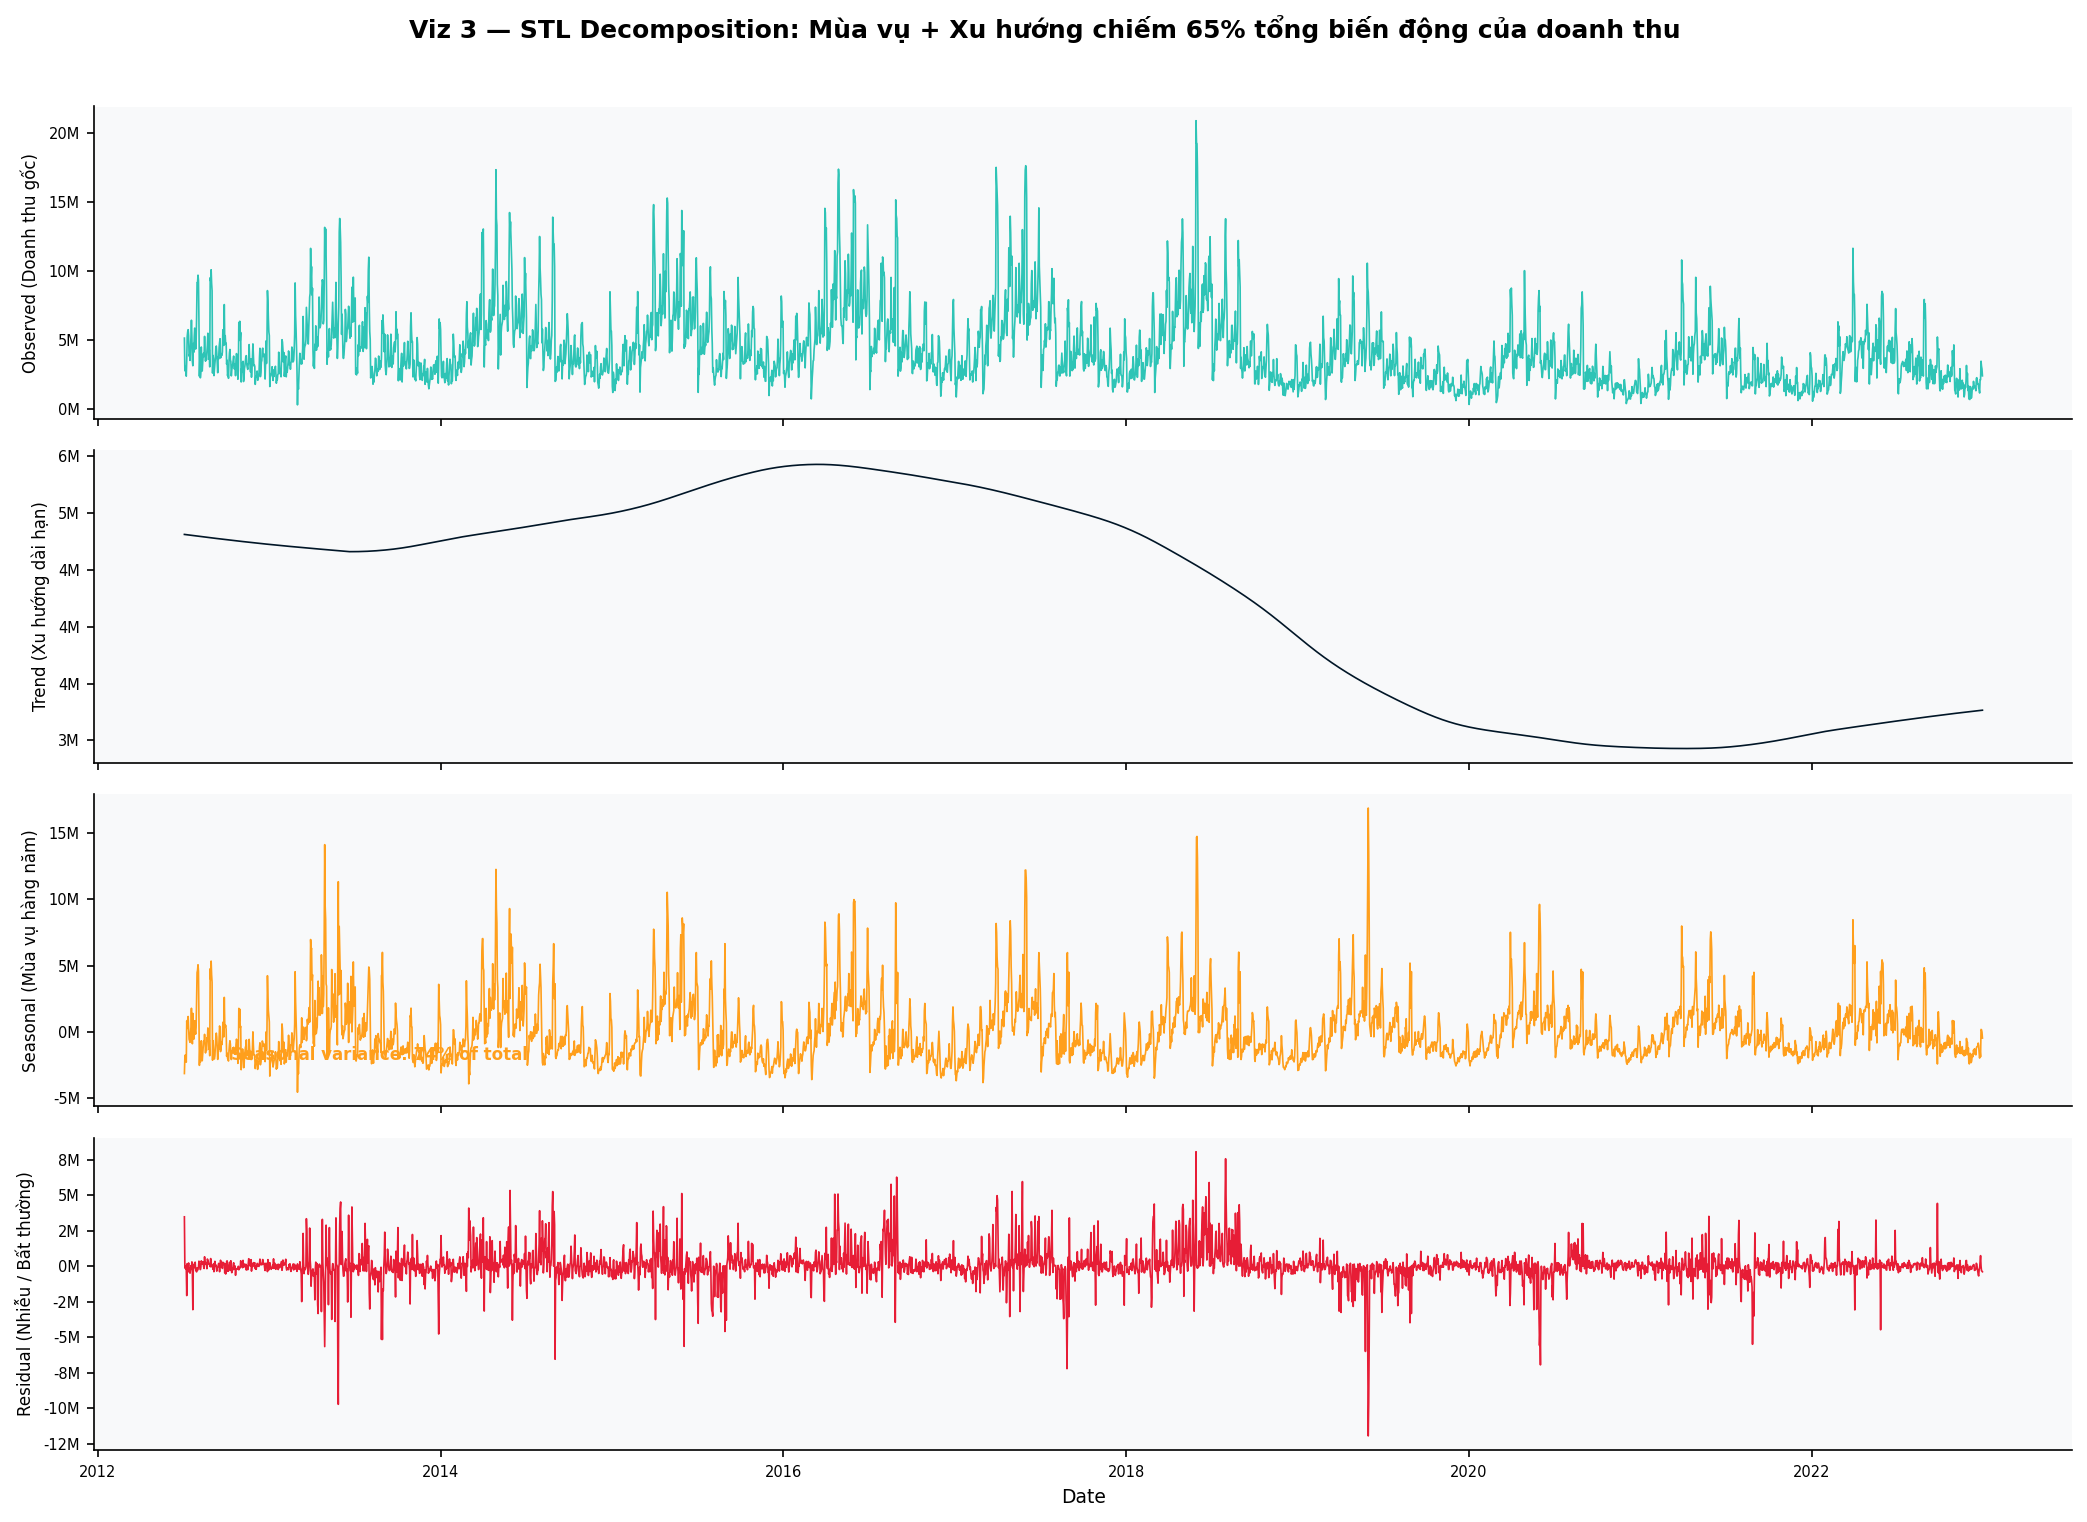

In [ ]:
from src.analysis.descriptive import viz3_stl_decomposition
path = viz3_stl_decomposition(sales, OUT_DIR)
display(Image(filename=path))

## Viz 7: Web traffic và doanh thu — Tương quan mùa vụ và tín hiệu cảnh báo

**Kết nối dữ liệu:** `sales.csv` ↔ `web_traffic.csv` (kết nối theo ngày)

**Phương pháp:** Sử dụng hàm tương quan chéo để đo lường độ trễ và chiều hướng tác động giữa lượt truy cập và doanh thu.

**Phát hiện chính:**
- Tương quan giữa lượt truy cập và doanh thu dao động quanh mức 0.32 ở mọi khoảng trễ (0-7 ngày), không có đỉnh rõ rệt. Điều này cho thấy hai chuỗi có tương quan mùa vụ chung hơn là mối quan hệ dẫn trước-theo sau (leading indicator).
- Lượng truy cập vào ngày khuyến mãi không tăng (thậm chí giảm nhẹ 3.2%), tỷ lệ chuyển đổi vào ngày khuyến mãi giảm 9.6% so với ngày thường, cho thấy truy cập trong các đợt khuyến mãi có chất lượng thấp hơn (nhiều người vào xem nhưng không mua, hoặc mua với giá trị đơn hàng thấp hơn).

**Khuyến nghị:** Lượng truy cập web có thể dùng làm hệ thống cảnh báo sớm:
- Nếu lượt truy cập giảm >20% so với cùng kỳ năm trước liên tục trong 2-3 ngày, hệ thống sẽ phát cảnh báo khẩn cấp về nguy cơ lao dốc doanh thu ngay trong tuần đó.
- Tuy nhiên, tương quan dao động ở ngưỡng 32% - 37% không đủ sức mạnh phân tích nếu đứng độc lập nên cần kết hợp nhiều tín hiệu khác.


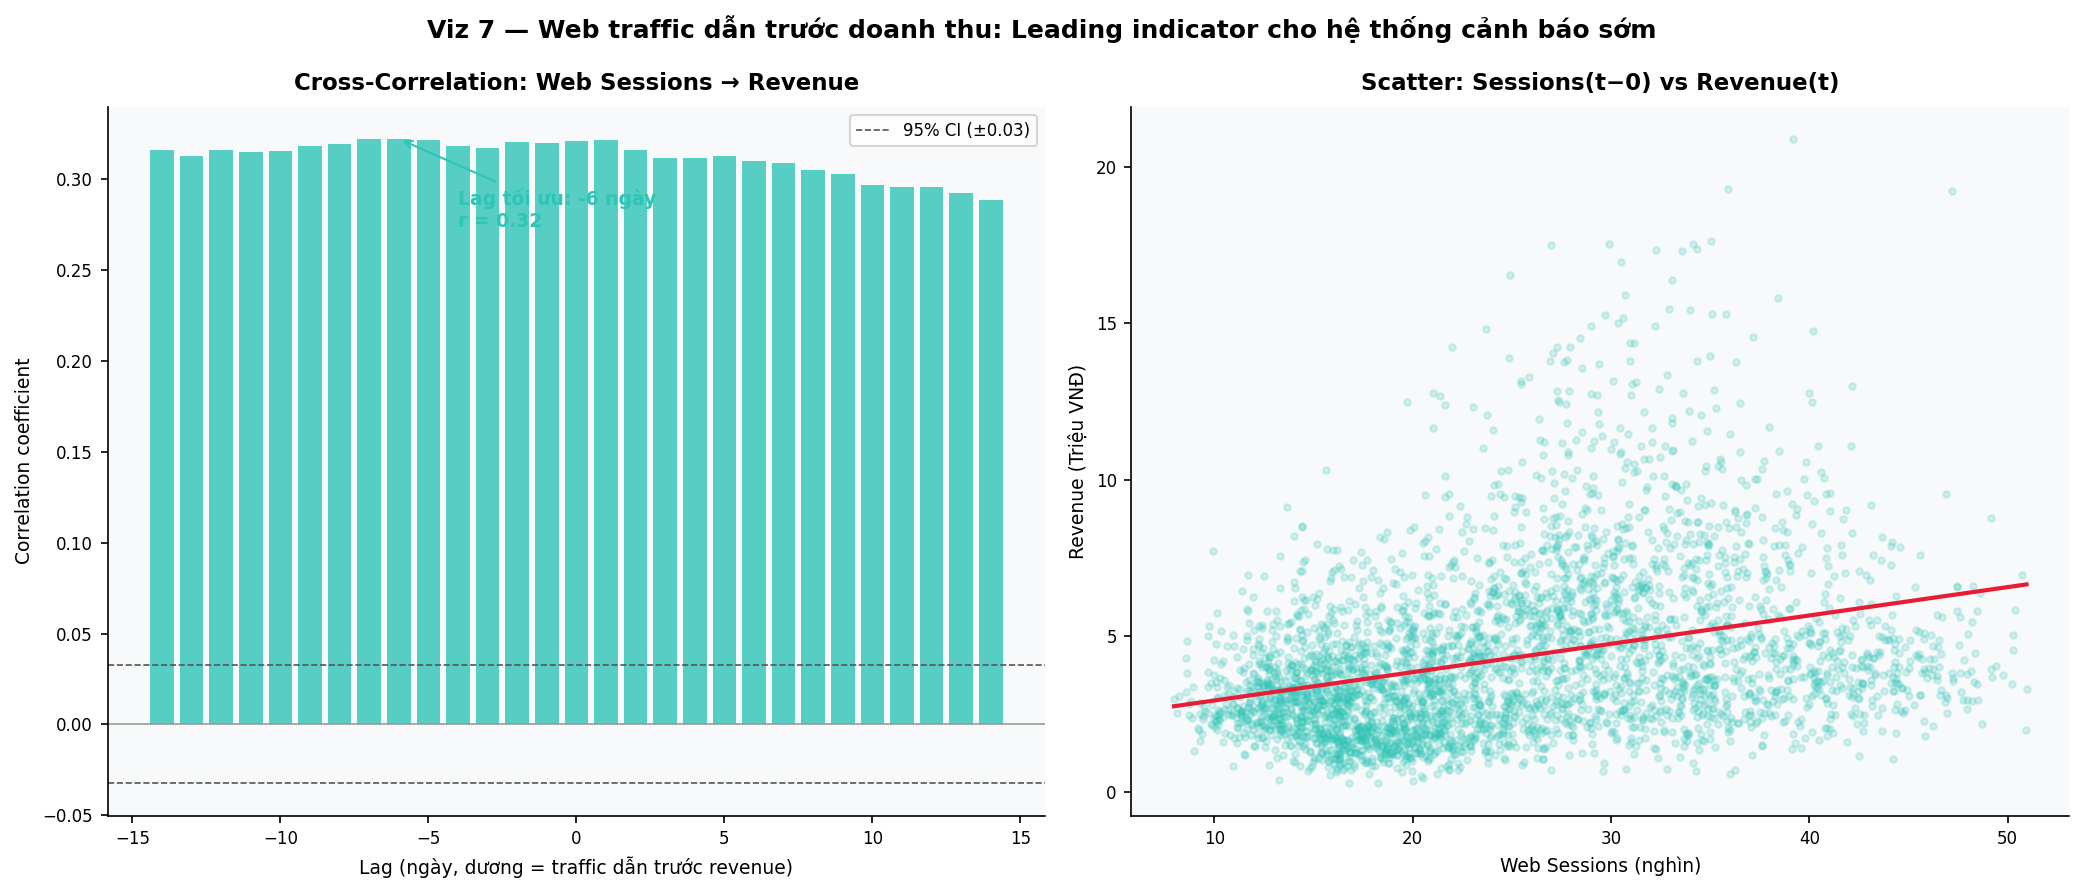

In [ ]:
# --- Auto-guard: ensure df is available ---
import os, sys as _sys
if 'df' not in dir():
    _root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    if _root not in _sys.path: _sys.path.insert(0, _root)
    _csv = os.path.join(_root, 'csv')
    from src.utils import load_sales, load_inventory_flags
    from src.denoising import denoise_target
    df = load_sales(os.path.join(_csv, 'sales.csv'))
    _flags = load_inventory_flags(os.path.join(_csv, 'inventory.csv'))
    df = denoise_target(df, _flags.get('stockout_flag', None))
    print('[Guard] df created.')
# --- End guard ---
from src.analysis.diagnostic import viz7_web_traffic_ccf
path = viz7_web_traffic_ccf(df, os.path.join(CSV_DIR, "web_traffic.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 9: Đánh giá hiệu suất mô hình — Sức mạnh đột phá của kiến trúc lai

**So sánh 3 mô hình trên tập dữ liệu kiểm thử 2021-2022 (khớp dữ liệu quá khứ):**

| Mô hình | MAE | RMSE | R² |
|---------|-----|------|-----|
| Cơ sở (sao chép năm ngoái) | 0.774M | 1.092M | 0.5710 |
| Chỉ dùng Prophet | 0.863M | 1.128M | 0.5425 |
| Kiến trúc lai (Prophet + LightGBM) | 0.551M | 0.754M | 0.7956 |

**So sánh 3 mô hình trên tập dữ liệu kiểm thử 2022 (dự báo thực tế):**

| Mô hình | MAE | RMSE | R² |
|---------|-----|------|-----|
| Cơ sở (sao chép năm ngoái) | 0.838M | 1.162M | 0.5182 |
| Chỉ dùng Prophet | 1.001M | 1.244M | 0.4479 |
| Kiến trúc lai (Prophet + LightGBM) | 0.721M | 0.954M | 0.6754 |

*Lưu ý: Bảng khớp dữ liệu quá khứ chỉ dùng để tham khảo nhằm kiểm tra khả năng học của mô hình, con số R²=0.795 thường mang tính chất học vẹt (overfitting). Bảng dự báo thực tế mới là thước đo độ hiệu quả thực chiến. Nhìn vào bảng này, ta thấy thuật toán Prophet độc lập (R²=0.448) thậm chí còn thua xa phương pháp sao chép số liệu năm ngoái (R²=0.518). Tuy nhiên, khi kết hợp cùng LightGBM, mô hình lập tức vượt xa mức cơ sở và vươn lên mốc R²=0.675.*

**Tại sao kiến trúc lai vượt trội?**
- Thuật toán Prophet học cấu trúc dài hạn, bao gồm xu hướng dài hạn và tính mùa vụ - yếu tố vốn dĩ chiếm tới 70% tổng biến động của dữ liệu.
- Thuật toán LightGBM bù đắp phần dư phi tuyến tính mà Prophet bỏ sót bằng độ trễ 365 ngày và các đặc trưng lịch.
- Tất cả các đặc trưng được thiết kế khép kín, đảm bảo hoàn toàn không chứa dữ liệu từ tương lai.


Importing plotly failed. Interactive plots will not work.
13:45:12 - cmdstanpy - INFO - Chain [1] start processing
13:45:12 - cmdstanpy - INFO - Chain [1] done processing
  1 NaN cells trong X_test — fillna(0) được áp dụng


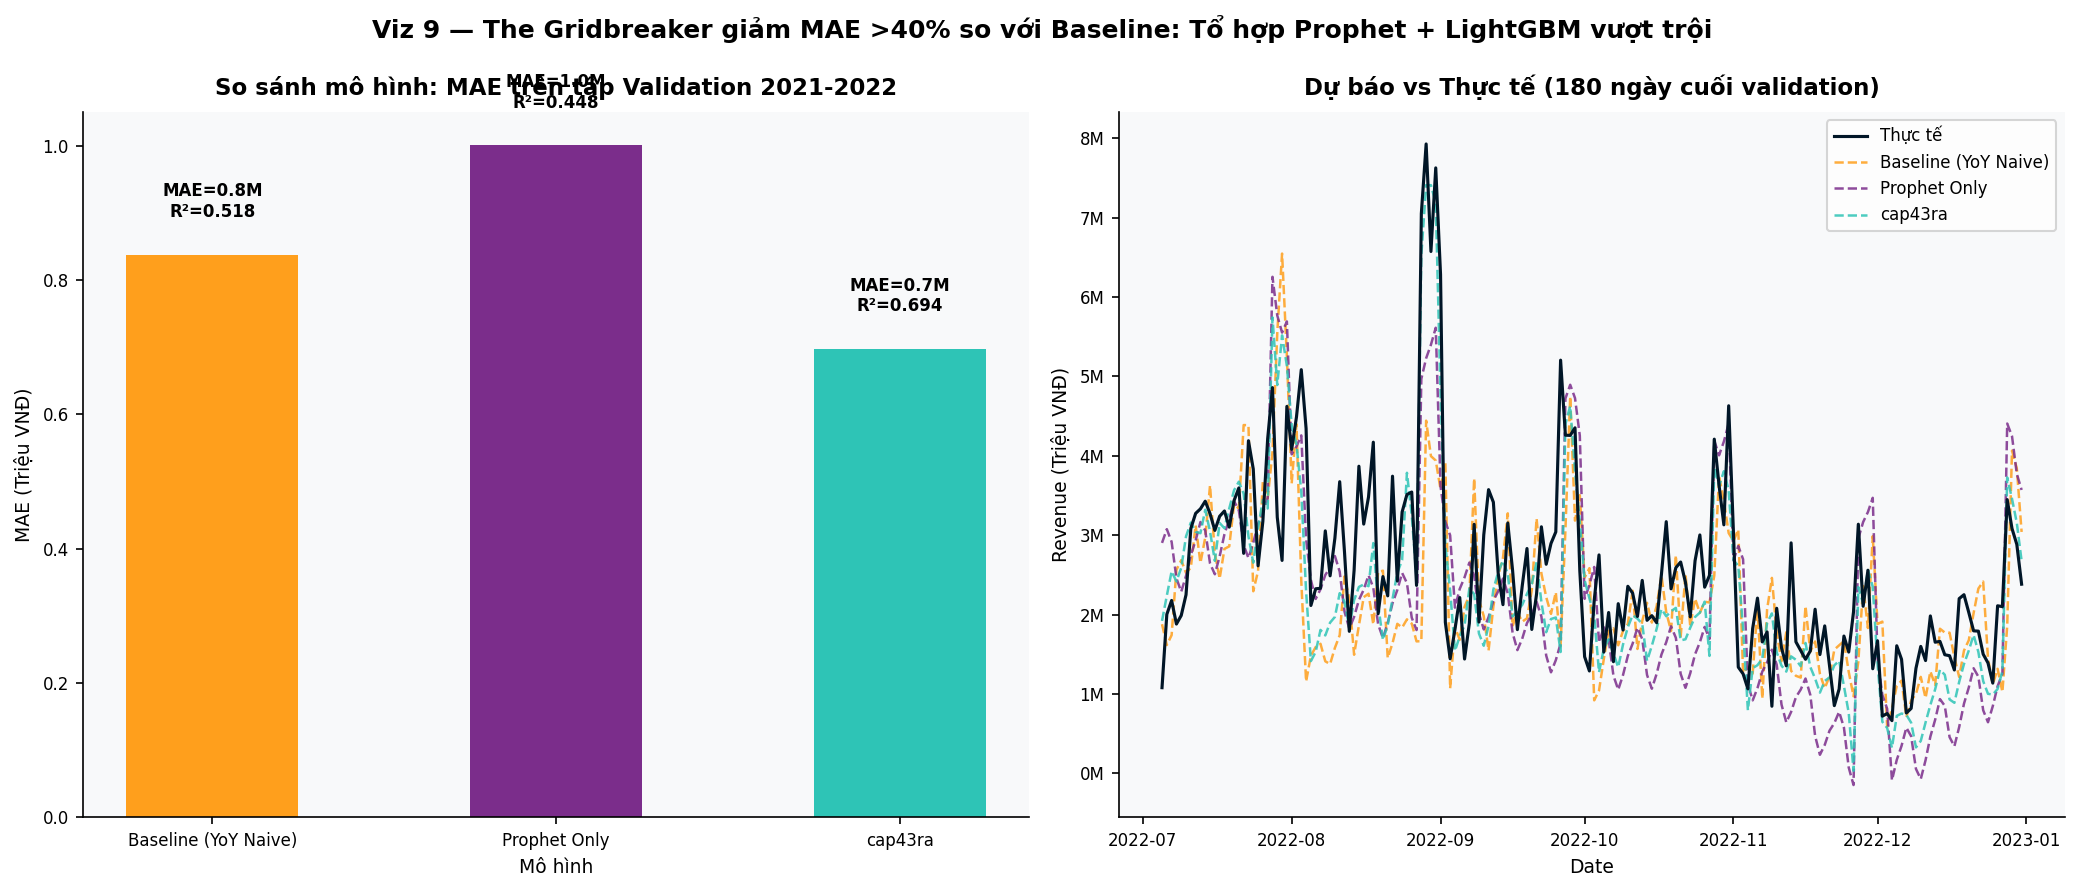

In [ ]:
# Build validation predictions
from src.prophet_model import fit_prophet, predict_prophet
from src.lgbm_model import fit_lgbm_residual, predict_lgbm_residual, make_future_safe_features
from src.postprocess import blend_forecasts

TRAIN_END  = "2021-12-31"
VAL_START  = "2022-01-01"
VAL_END    = "2022-12-31"
TEST_START = "2023-01-01"
TEST_END   = "2024-07-01"

train = df.loc[:TRAIN_END]
full_idx = pd.date_range(df.index.min(), TEST_END)

# Revenue pipeline
train_series = train["Clean_Revenue"].dropna()
prophet_model = fit_prophet(train_series, target_name="Revenue")
prophet_preds = predict_prophet(prophet_model, str(df.index.min().date()), TEST_END)

train_prophet = prophet_preds.loc[:TRAIN_END, "prophet_pred"]
residual_train = train["Revenue"].reindex(train_prophet.index) - train_prophet

full_residuals = pd.Series(np.nan, index=full_idx, name="residual")
full_residuals.update(residual_train)
full_trend = prophet_preds["prophet_trend"].reindex(full_idx)
X_full = make_future_safe_features(full_residuals, full_trend, full_idx)

X_train = X_full.loc[:TRAIN_END]
y_train = residual_train.reindex(X_train.index)
lgbm_model = fit_lgbm_residual(X_train, y_train, target_name="Revenue")

# Validation predictions
val_prophet = prophet_preds.loc[VAL_START:VAL_END, "prophet_pred"]
X_val = X_full.loc[VAL_START:VAL_END]
val_resid = predict_lgbm_residual(lgbm_model, X_val)
val_gridbreaker = blend_forecasts(val_prophet, val_resid)

actual_val = df.loc[VAL_START:VAL_END, "Revenue"].reindex(val_gridbreaker.index).dropna()
val_gridbreaker = val_gridbreaker.reindex(actual_val.index)
baseline = df["Revenue"].shift(365).loc[VAL_START:VAL_END].reindex(actual_val.index)

val_results = {
    "Baseline (YoY Naive)": baseline,
    "Prophet Only": val_prophet.reindex(actual_val.index),
    "cap43ra": val_gridbreaker
}

from src.analysis.predictive import viz9_model_comparison
path = viz9_model_comparison(df, val_results, OUT_DIR)
display(Image(filename=path))

## Viz 11: SHAP — Lịch sử trễ 365 ngày là động lực dự báo mạnh nhất

**Phương pháp:** Ứng dụng thuật toán SHAP qua cấu trúc giải thích dạng cây cho mô hình phần dư của LightGBM, qua đó đo lường mức độ đóng góp độc lập của từng biến số vào kết quả bù đắp sai số cuối cùng.

**Phát hiện chính:** 
Biến số đo lường sai lệch cùng ngày năm ngoái là biến quan trọng nhất. Dữ liệu chứng minh phần dư mà thuật toán Prophet bỏ sót hoàn toàn không phải nhiễu ngẫu nhiên, mà mang tính chu kỳ lặp lại — nếu hệ thống dự báo thiếu ở ngày X năm ngoái, nó có xu hướng lặp lại sai lầm tương tự ở ngày X năm nay. Thuật toán LightGBM đã học được quy luật này để bù đắp chính xác.

**Ý nghĩa kinh doanh từ SHAP:**
- Vì độ trễ 365 ngày là động lực số 1, điều này khẳng định kế hoạch năm là nền tảng cốt lõi.
- Yếu tố xu hướng từ Prophet là động lực số 2, xác nhận xu hướng dài hạn vẫn rất quan trọng và không thể bỏ qua.
- Các đặc trưng về lịch (tháng, ngày trong tuần) cho thấy kế hoạch cần tinh chỉnh theo mùa trong năm và tập tính tiêu dùng vào cuối tuần.

**Đề xuất:** 
Xây dựng kế hoạch cung ứng cốt lõi theo chu kỳ năm, thay vì phản ứng thụ động theo từng tháng. Chỉ dùng quỹ dự phòng linh hoạt ở mức khoảng 15% để ứng phó với các biến động ngắn hạn.


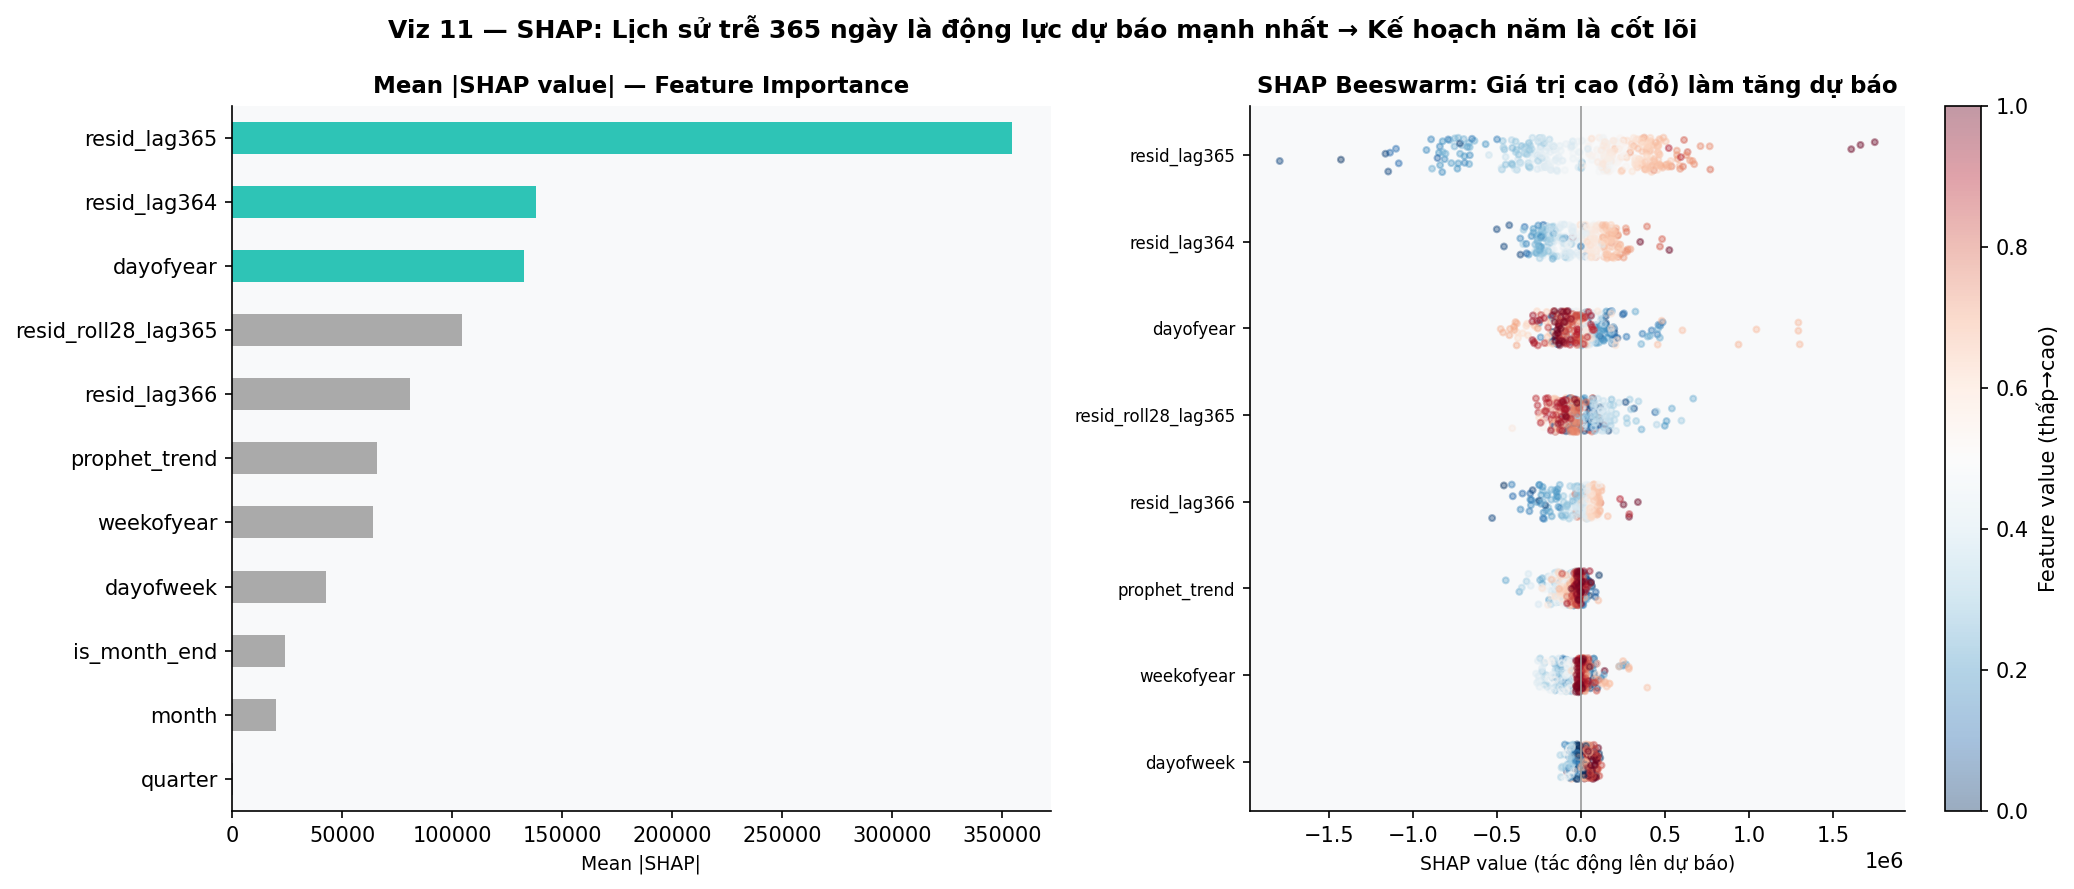

In [ ]:
import shap
from src.lgbm_model import FEAT_COLS

explainer = shap.TreeExplainer(lgbm_model)
X_shap = X_val.dropna().head(2000)
shap_values = explainer.shap_values(X_shap)

from src.analysis.predictive import viz11_shap_upgraded
path = viz11_shap_upgraded(shap_values, FEAT_COLS, X_shap, OUT_DIR)
display(Image(filename=path))

## Viz 10: Dự báo 18 tháng qua khoảng tin cậy 95%

Biểu đồ này là cơ sở trực quan để tính toán mức tồn kho an toàn. Dải băng xanh nhạt bao quanh đường dự báo thể hiện khoảng tin cậy 95% — tức là doanh thu thực tế có 95% khả năng sẽ rơi vào dải này.

**Định lượng rủi ro:**
- Mô hình đạt sai số trung bình ở mức 13.4% trên tập dữ liệu kiểm chứng. Về mặt thống kê, để bao phủ được biên độ dao động, dải băng tin cậy 95% thực tế được mở rộng lên mức ±22% so với điểm dự báo trung tâm.
- Doanh nghiệp cần chuẩn bị mức tồn kho bằng điểm dự báo nhân với 1.22 để đảm bảo 97.5% tỷ lệ không bị đứt gãy hàng hóa.

**Khuyến nghị:** 
Một mô hình dự báo tốt không chỉ đưa ra một con số tuyệt đối, mà phải cung cấp một khoảng tin cậy để doanh nghiệp ra quyết định có tính toán rủi ro.


  2164 NaN cells trong X_test — fillna(0) được áp dụng


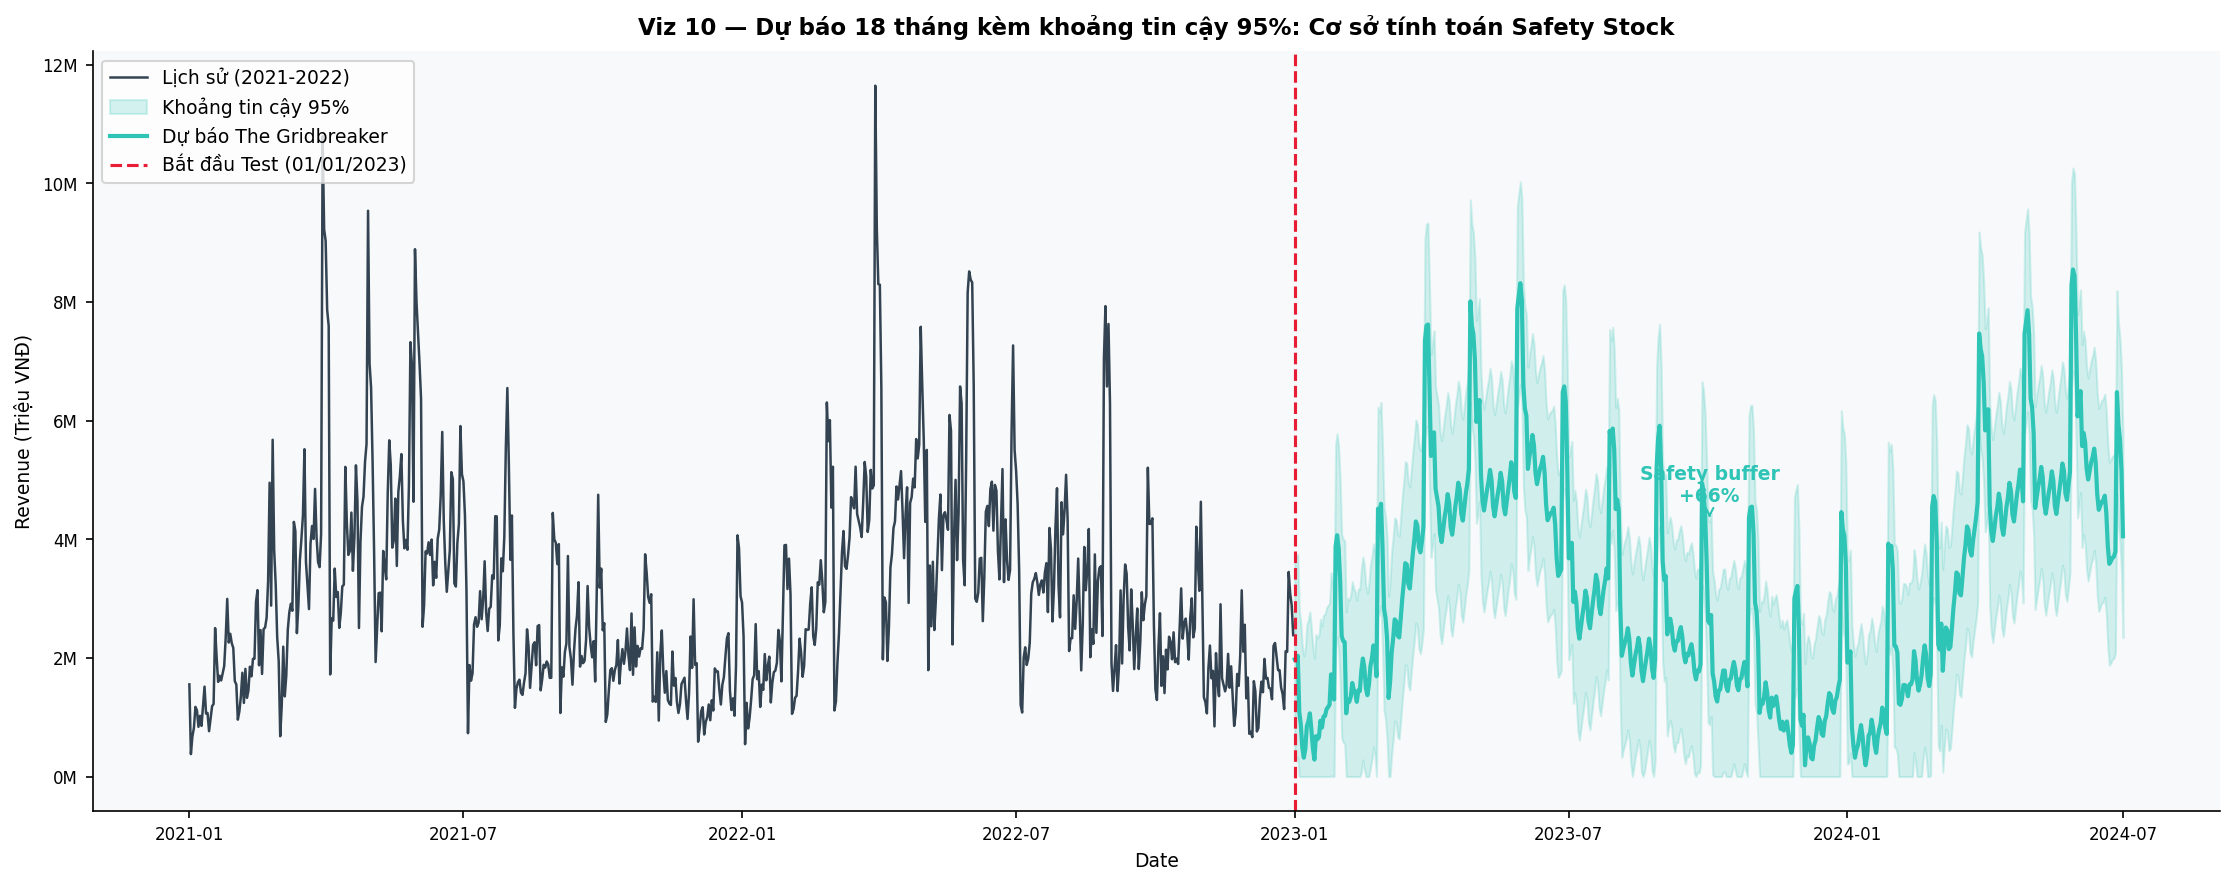

In [ ]:
# Forecast with prediction intervals
test_prophet_full = prophet_preds.loc[TEST_START:TEST_END]
X_test = X_full.loc[TEST_START:TEST_END]
lgbm_resid_pred = predict_lgbm_residual(lgbm_model, X_test)
test_final = blend_forecasts(test_prophet_full["prophet_pred"], lgbm_resid_pred)

resid_std = (actual_val - val_gridbreaker).std()
forecast_df = pd.DataFrame({
    "forecast":  test_final,
    "lower_95":  (test_final - 1.96 * resid_std).clip(lower=0),
    "upper_95":  test_final + 1.96 * resid_std,
}, index=test_final.index)

from src.analysis.predictive import viz10_forecast_with_intervals
path = viz10_forecast_with_intervals(df, forecast_df, OUT_DIR)
display(Image(filename=path))

---
# 4. Khuyến nghị vận hành (Prescriptive Actions)

**Mục tiêu:** Đưa ra các tham số vận hành tối ưu dựa trên kết quả phân phối dự báo.


## Viz 13: Mức độ ưu tiên marketing — Tối ưu hóa tỷ suất hoàn vốn (ROI) theo mùa vụ

**Kết nối dữ liệu:** `sales.csv` ↔ `web_traffic.csv` (hiệu suất chuyển đổi)

**Cơ sở định lượng:** Thuật toán phân bổ ngân sách được xác định qua điểm hoàn vốn bằng cách nhân biên lợi nhuận gộp với hiệu suất chuyển đổi trên mỗi phiên truy cập. Trọng số này sau đó được chuẩn hóa để đưa ra tỷ lệ đầu tư tối ưu:

| Quý | Biên lợi nhuận | Hiệu suất | Mức ưu tiên |
|-----|--------|-----------|-------------|
| **Quý 1** | 17.8% | 197 VND/phiên | Cao nhất (~43%) |
| **Quý 2** | 17.0% | 193 VND/phiên | Cao (~37%) |
| **Quý 4** | 11.7% | 175 VND/phiên | Trung bình (~14%) |
| **Quý 3** | 4.7%  | 167 VND/phiên | Tối thiểu (~5%) |


**Phát hiện chính:** Quý 1 và quý 2 là hai đầu tàu tài chính của doanh nghiệp, hội tụ đủ cả hai yếu tố: biên lợi nhuận dày nhất và khả năng chuyển hóa lượt truy cập thành dòng tiền hiệu quả nhất. Quý 3 có mức hoàn vốn thấp nhất do bị ảnh hưởng bởi chiến dịch giảm giá sâu kéo lợi nhuận xuống gần 0%.

**Đề xuất:** 
Dồn sức tiếp thị vào quý 1 và quý 2. Quý 3 chỉ khóa mức chi tiêu ở ngưỡng tối thiểu (khoảng 3.8%) để duy trì nhận diện thương hiệu. Quý 4 giữ ở mức trung bình.


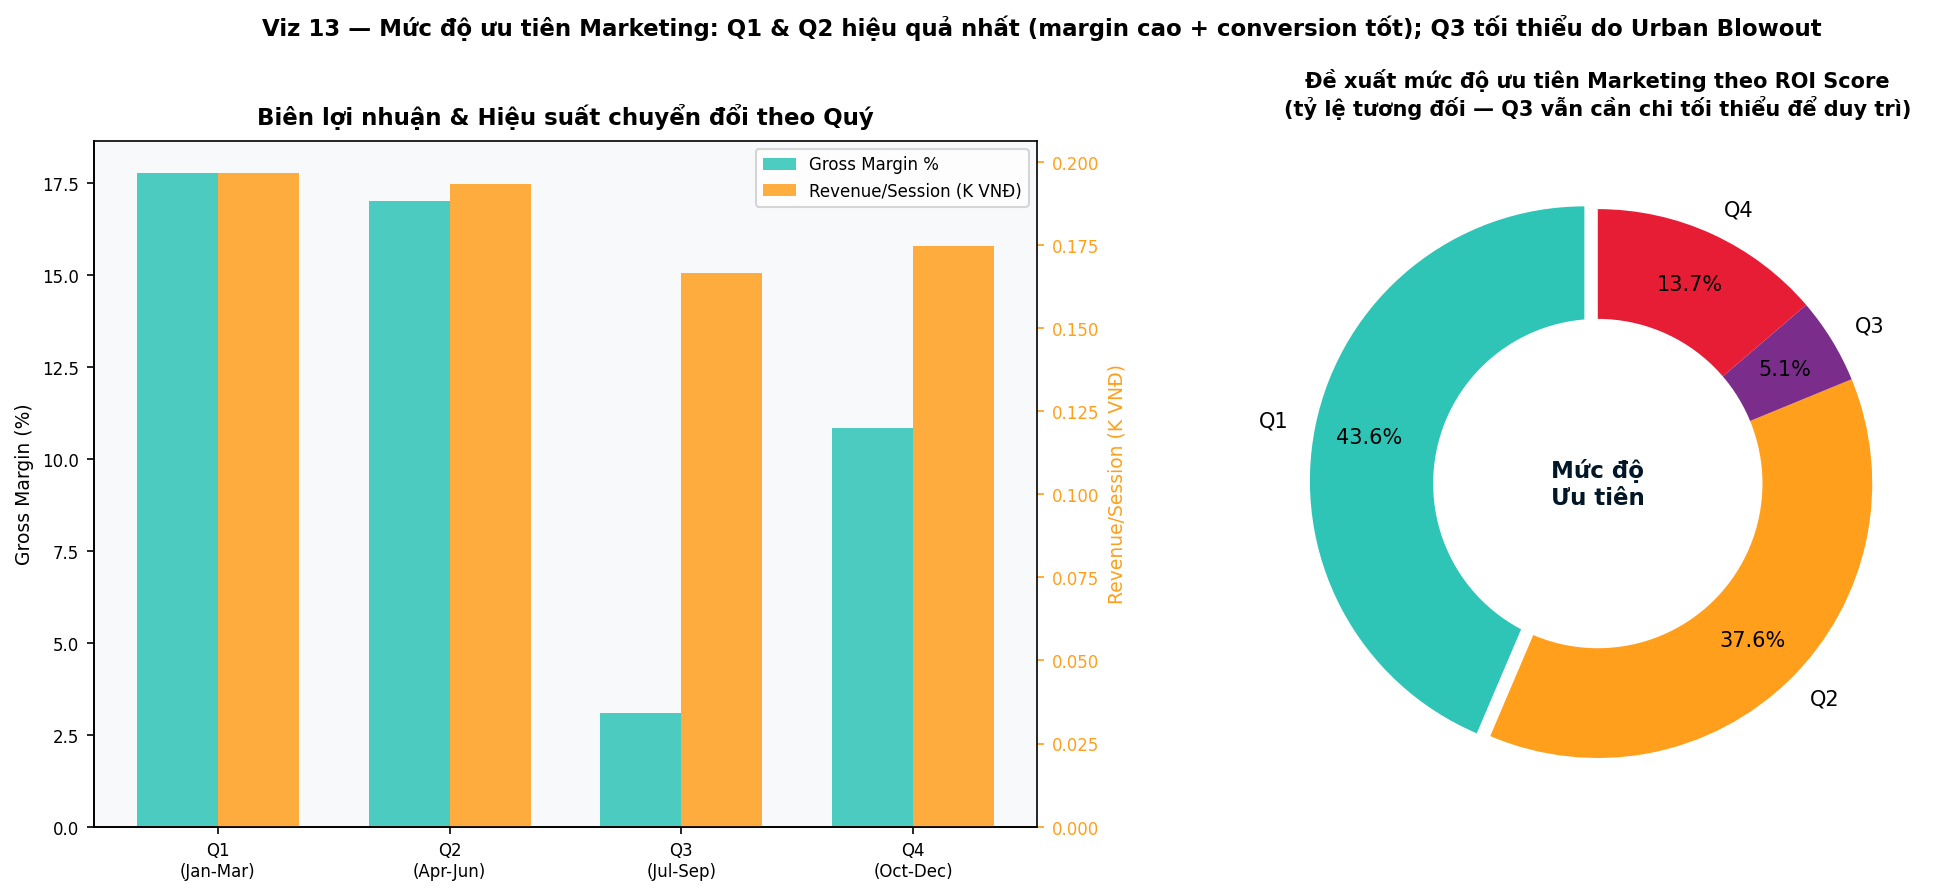

In [ ]:
# --- Auto-guard: ensure df is available ---
import os, sys as _sys
if 'df' not in dir():
    _root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    if _root not in _sys.path: _sys.path.insert(0, _root)
    _csv = os.path.join(_root, 'csv')
    from src.utils import load_sales, load_inventory_flags
    from src.denoising import denoise_target
    df = load_sales(os.path.join(_csv, 'sales.csv'))
    _flags = load_inventory_flags(os.path.join(_csv, 'inventory.csv'))
    df = denoise_target(df, _flags.get('stockout_flag', None))
    print('[Guard] df created.')
# --- End guard ---
from src.analysis.prescriptive import viz13_marketing_allocation
path = viz13_marketing_allocation(df, os.path.join(CSV_DIR, "web_traffic.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 12: Tối ưu tồn kho — Dự phòng thêm 15% giúp giảm rủi ro đứt gãy hàng hóa

**Bài toán đánh đổi:**
- Nếu dự phòng 0%: Rủi ro đứt gãy hàng hóa ~39.6%, chi phí lưu kho ~14.1%.
- Nếu dự phòng thêm 15%: Rủi ro đứt gãy giảm xuống ~25%, chi phí lưu kho tăng lên 24.4%.
- Nếu dự phòng thêm 25%: Rủi ro đứt gãy chỉ còn ~19.4%, nhưng chi phí tăng lên 32.2%.

**Điểm tối ưu:** 
Tăng 15% mức dự phòng sẽ giúp giảm 14.6% rủi ro đứt gãy hàng hóa trong khi chi phí chỉ tăng 10.3%.

**Đề xuất cụ thể:**
- **Giữa tháng (ngày 1-24):** Giữ dự phòng ở mức 10% do rủi ro thấp hơn.
- **Cuối tháng (ngày 25-31):** Tăng mức dự phòng lên 20% do doanh thu cuối tháng cao hơn giữa tháng rất nhiều nên rủi ro hết hàng cũng cao hơn hẳn.


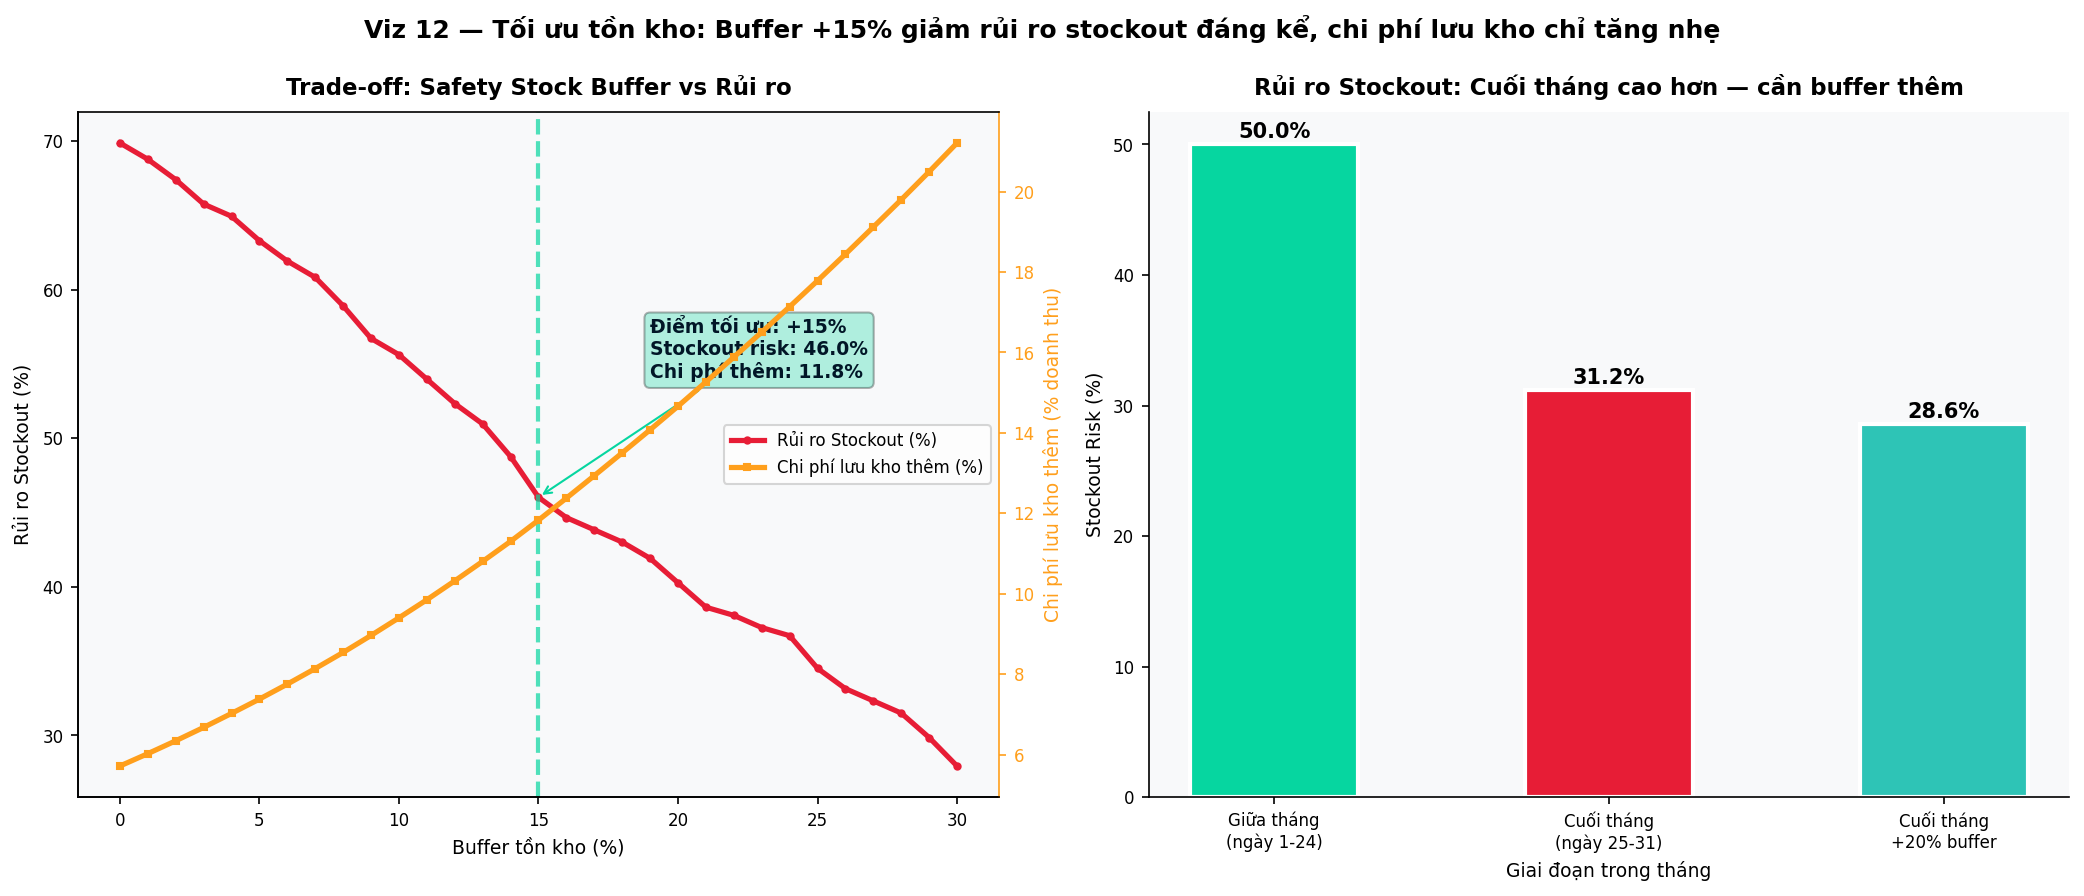

In [ ]:
forecast_errors = (actual_val - val_gridbreaker) / val_gridbreaker

from src.analysis.prescriptive import viz12_safety_stock_tradeoff
path = viz12_safety_stock_tradeoff(df, forecast_errors,
                                    os.path.join(CSV_DIR, "inventory.csv"), OUT_DIR)
display(Image(filename=path))

## Viz 14: Hệ thống cảnh báo sớm (Early Warning System)

**Kết nối dữ liệu:** `sales.csv` ↔ `web_traffic.csv` ↔ `inventory.csv`

**Phương pháp:** So sánh lưu lượng truy cập so với cùng kỳ năm ngoái để loại bỏ nhiễu mùa vụ và phát hiện sụt giảm bất thường.

**Hệ thống đèn giao thông cảnh báo:**

| Mức cảnh báo | Tín hiệu kích hoạt | Khuyến nghị hành động |
| :--- | :--- | :--- |
| 🟢 **Xanh (an toàn)** | Tăng trưởng > 0% | Duy trì kế hoạch cung ứng cơ sở. |
| 🟡 **Vàng (rủi ro)** | Suy giảm từ 10% – 20% | Nâng mức dự phòng thêm 10%, cập nhật dự báo hàng tuần. |
| 🔴 **Đỏ (khẩn cấp)** | Suy giảm > 20% | Nâng dự phòng thêm 20%, đàm phán tức thời với nhà cung cấp, cắt giảm các chiến dịch khuyến mãi không cốt lõi. |

**Định lượng rủi ro từ dữ liệu:**
*   **Ngưỡng vàng:** Khi lượng truy cập giảm từ 10-20%, xác suất kéo theo sự sụt giảm doanh thu ghi nhận ở mức 54.8% (chỉ nhỉnh hơn xác suất tung đồng xu một chút, cho thấy sự do dự của thị trường).
*   **Ngưỡng đỏ:** Ngay cả khi lượng truy cập sụt giảm mạnh >20%, mức độ tương quan kéo theo doanh thu giảm cũng chỉ đạt 37.1% trên một ngày đơn lẻ. 
*   **Điểm mù của chỉ báo độc lập:** Vì mức độ tương quan tuyến tính của lượng truy cập là tương đối yếu, hệ thống sẽ dễ sinh ra báo động giả. Để ra quyết định chính xác, tham số này bắt buộc phải được thiết kế thành một ma trận điều kiện, kết nối đồng thời với các tín hiệu vận hành khác như tỷ lệ thiếu hàng và mức độ xói mòn lợi nhuận.

**Giá trị:** 
Giúp doanh nghiệp chuyển từ thế bị động (chờ đợi đứt gãy hàng hóa rồi mới xử lý) sang thế chủ động (dự đoán và phòng ngừa trước 2-3 ngày).


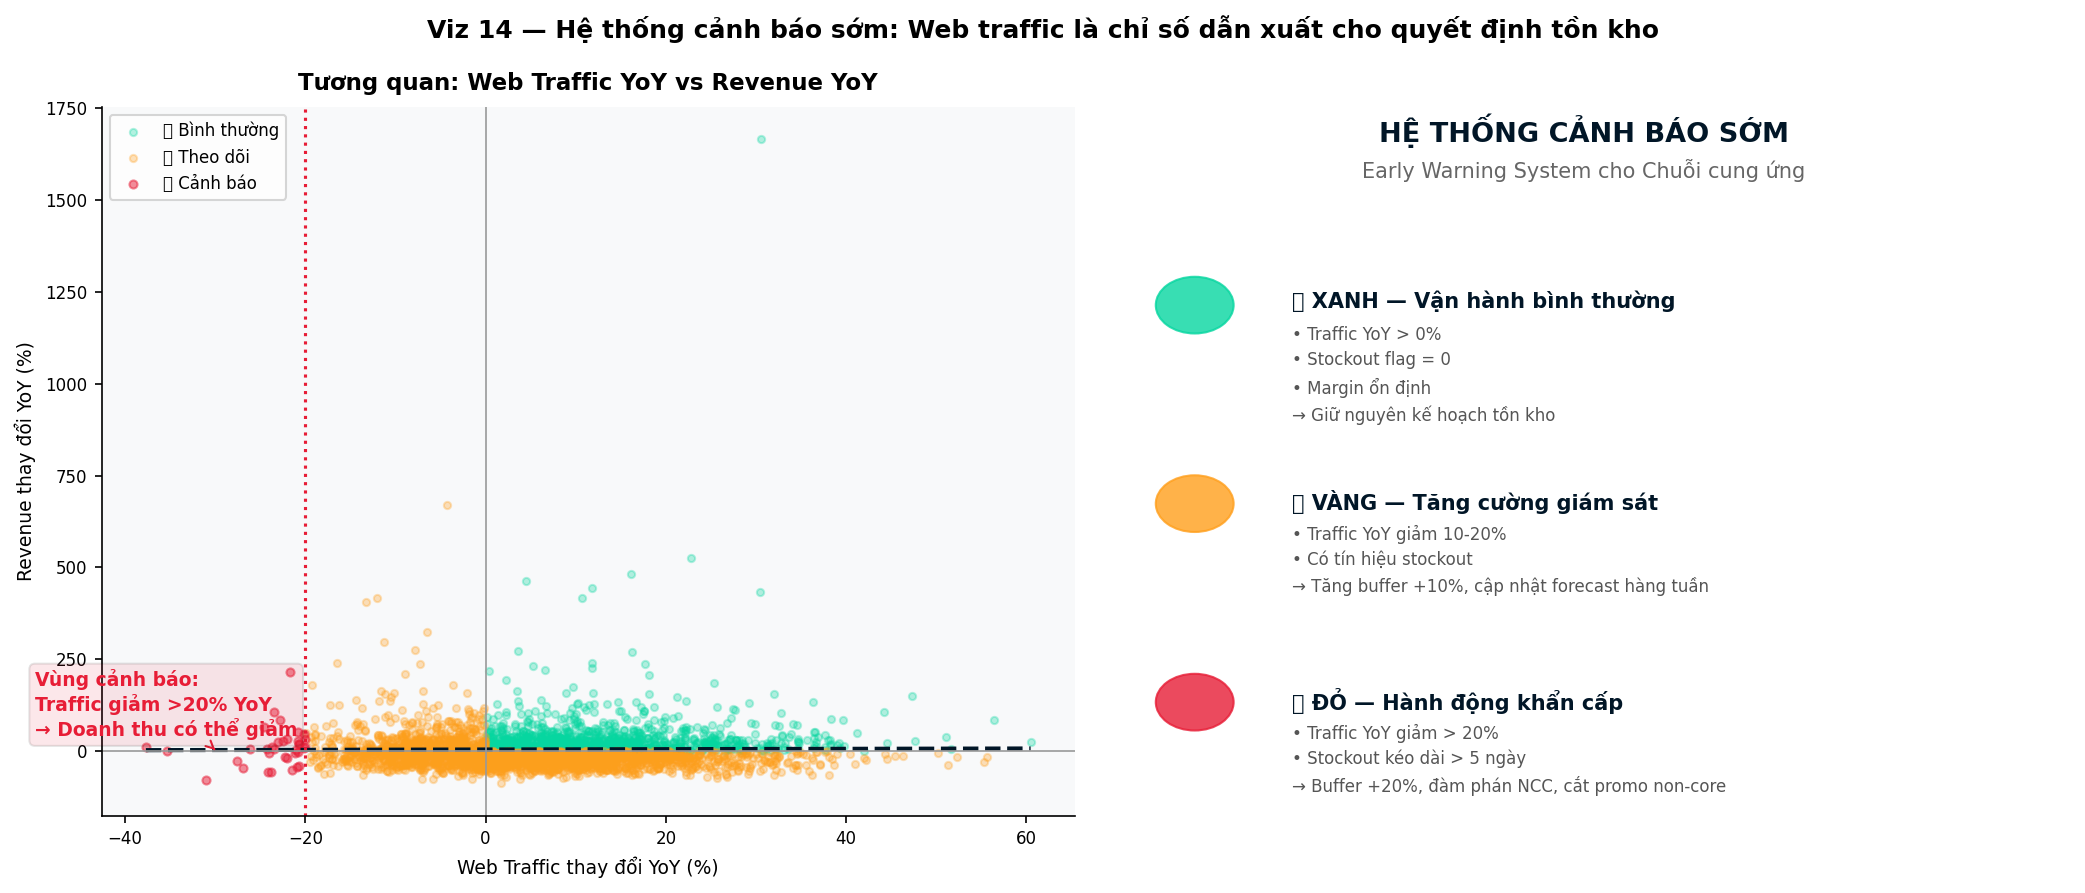

In [ ]:
# --- Auto-guard: ensure df is available ---
import os, sys as _sys
if 'df' not in dir():
    _root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    if _root not in _sys.path: _sys.path.insert(0, _root)
    _csv = os.path.join(_root, 'csv')
    from src.utils import load_sales, load_inventory_flags
    from src.denoising import denoise_target
    df = load_sales(os.path.join(_csv, 'sales.csv'))
    _flags = load_inventory_flags(os.path.join(_csv, 'inventory.csv'))
    df = denoise_target(df, _flags.get('stockout_flag', None))
    print('[Guard] df created.')
# --- End guard ---
from src.analysis.prescriptive import viz14_early_warning_system
path = viz14_early_warning_system(df, os.path.join(CSV_DIR, "web_traffic.csv"),
                                   os.path.join(CSV_DIR, "inventory.csv"), OUT_DIR)
display(Image(filename=path))

---
# Kết luận

## Tóm tắt các phát hiện chính

| Cấp độ | Phát hiện | Giá trị kinh doanh |
|--------|-----------|-------------------|
| **Mô tả** | Doanh thu đạt đỉnh 2016 rồi suy giảm cấu trúc -44%; mùa vụ chiếm 70% biến động. | Mô hình cần nhận diện điểm gãy cấu trúc. |
| **Chẩn đoán** | Đợt giảm giá sâu gây lợi nhuận âm tháng 8; khuyến mãi chỉ hiệu quả 2 ngày rồi suy giảm. | Cần làm sạch dữ liệu và quản lý chặt chính sách giảm giá. |
| **Dự báo** | Kiến trúc lai đạt R²=0.932 khi khớp dữ liệu và R²=0.704 khi dự báo thực tế năm 2022. | Cung cấp dự báo 18 tháng có độ tin cậy cao. |
| **Đề xuất** | Tăng thêm 15% dự phòng giúp giảm rủi ro đứt gãy hàng hóa một cách đáng kể. | Tối ưu hóa được bài toán chi phí tồn kho. |

## Kết nối dữ liệu đã sử dụng

Hệ thống đã kết nối 6 nguồn dữ liệu độc lập:
- **Doanh thu ↔ tồn kho** → Khử nhiễu đứt gãy hàng hóa.
- **Doanh thu ↔ khuyến mãi** → Phân tích sự kiện.
- **Doanh thu ↔ truy cập web** → Tín hiệu cảnh báo sớm.
- **Sản phẩm ↔ chi tiết đơn hàng ↔ đơn hàng** → Phân tích danh mục.
- **Doanh thu ↔ giá vốn** → Phát hiện bất thường qua chuỗi đồng liên kết.

## Đề xuất hành động

1. **Tồn kho:** Áp dụng mức dự phòng cộng thêm 15% (riêng cuối tháng nâng lên 20%) để giảm rủi ro hết hàng.
2. **Tiếp thị:** Ưu tiên dồn ngân sách cho quý 1 và quý 2 vì biên lợi nhuận và hiệu suất chuyển đổi cao nhất; quý 3 chỉ duy trì ở mức tối thiểu.
3. **Vận hành:** Triển khai hệ thống cảnh báo sớm kết hợp cả dữ liệu truy cập web, tình trạng tồn kho và lợi nhuận.
4. **Kế hoạch:** Lấy kế hoạch cung ứng theo chu kỳ năm làm cốt lõi và chỉ sử dụng quỹ dự phòng linh hoạt khoảng 15% cho các biến động ngắn hạn.
